<a href="https://colab.research.google.com/github/ksdhariwal/Machine-Learning/blob/main/Used-Car-Analysis/Used_Car_Regression_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Table of Contents

1. **Business Understanding**
   - Project goals
   - Key business questions
   - Success criteria
   - Project Roadmap
   - Libraries and Initial Setup

2. **Data Understanding**
   - Loading the dataset
   - Dataset shape and structure
   - Summary statistics
   - Identifying numeric and categorical variables
   - Interpretation of variable types
   - Missing values
   - Interpretation of missing values
   - Data dictionary

3. **Exploratory Data Analysis (EDA)**
   - Price distribution
   - Mileage distribution
   - Vehicle year distribution
   - Fuel type distribution
   - Drive type distribution
   - Manufacturer distribution
   - Correlation heatmap
   - Initial observations summary

4. **Data Preparation**
   - Outlier Removal
   - Handling Missing Values
   - Feature engineering
   - Encoding categorical variables
   - Removing Identifier & High‑Cardinality Columns
   - Scaling Numerical Features
   - Train/test split

4. **Exploratory Data Analysis (EDA)**
   - Price distribution
   - Mileage distribution
   - Vehicle year distribution
   - Fuel type distribution
   - Drive type distribution
   - Manufacturer distribution
   - Correlation heatmap
   - Initial observations summary

5. **Modeling**
   - Linear Regression
   - Ridge Regression
   - Lasso Regression
   - Final Model Comparison and Interpretation

6. **Findings and Recommendations**

7. **Final Conclusion / Executive Summary**

# 1. Business Understanding

The goal of this project is to understand what drives the price of a used car and to build predictive models that help dealerships make data‑driven pricing and inventory decisions.

## Key Business Questions
- What characteristics make a used car more expensive?
- Which features decrease the value of a car?
- How do age, mileage, condition, and brand influence price?
- What actionable insights can help the dealership improve profitability?

## Success Criteria
- A clear ranking of the most important features that drive price.
- Visualizations that help non‑technical stakeholders understand pricing patterns.
- Multiple regression models with cross‑validation and hyperparameter tuning.
- Clean, organized notebook with correct interpretation of results.
- Actionable recommendations for dealership decision‑making.

## Project Roadmap

This project follows a structured workflow aligned with CRISP‑DM:

Understand the business problem  

*   Understand the business problem
*   Explore and understand the dataset  Clean and prepare the data  
*   Explore patterns visually  
*   Build and evaluate multiple models  
*   Compare model performance  
*   Summarize findings and provide recommendations  
*   Conclude with business value and next steps

## Libraries and Initial Setup

Before beginning the analysis, we import all required Python libraries for data manipulation, visualization, and modeling. This ensures a consistent environment throughout the notebook and keeps the workflow organized.

- **pandas / numpy** — data manipulation and numerical operations  
- **matplotlib / seaborn** — visualizations  
- **scikit‑learn** — preprocessing, model building, evaluation, and cross‑validation  
- **xgboost** — gradient boosting model for non‑linear patterns  
- **Helper functions** — reusable evaluation function for RMSE and R²  

The following code cell sets up the environment and defines a helper function used throughout the modeling sections.

In [ ]:
# ---------------------------------------------------------
# Libraries and Initial Setup
# ---------------------------------------------------------

# Data manipulation and numerical computing
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Machine learning tools: preprocessing, model selection, evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Tree-based models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------------
# Visualization settings
# ---------------------------------------------------------
sns.set(style="whitegrid", palette="deep")  # clean, readable plots
pd.set_option('display.max_columns', None)  # show all columns when inspecting data

# ---------------------------------------------------------
# Helper function for model evaluation
# ---------------------------------------------------------
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Evaluates a regression model using RMSE and R².

    Parameters:
        model: trained model object
        X_train, y_train: training data
        X_test, y_test: testing data

    Prints:
        Training RMSE, Testing RMSE
        Training R², Testing R²
    """

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # RMSE calculations
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # R² calculations
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)

    # Display results
    print(f"Training RMSE: {train_rmse:.4f}")
    print(f"Testing RMSE : {test_rmse:.4f}")
    print(f"Training R²  : {train_r2:.4f}")
    print(f"Testing R²   : {test_r2:.4f}")


# 2. Data Understanding

This section explores the structure, completeness, and basic characteristics of the used‑car dataset. The goal is to understand what data is available, identify missing or inconsistent values, and examine the distribution of key variables. A clear understanding of the dataset is essential before performing any cleaning, feature engineering, or modeling.

We follow the CRISP‑DM framework, beginning with a systematic inspection of the dataset using code-driven discovery rather than manually assuming which variables are important.

## 2.1 Loading the Dataset

We begin by loading the dataset into a pandas DataFrame.  
This allows us to inspect the raw structure of the data before performing any cleaning or transformations.

In [ ]:
# ---------------------------------------------------------
# Load the dataset
# ---------------------------------------------------------
df = pd.read_csv("sample_data/vehicles.csv")

# Display the first few rows to understand the structure
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


### 2.2 Dataset Shape and Structure

We check the number of rows and columns to understand dataset size.  
We also inspect data types and identify which columns are numerical or categorical.

In [ ]:
# ---------------------------------------------------------
# Dataset shape and structure
# ---------------------------------------------------------

print("Dataset shape:", df.shape)   # Number of rows and columns

# Data types and non-null counts
df.info()

Dataset shape: (426880, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880

### 2.3 Summary Statistics

Summary statistics help us understand the distribution of numerical variables such as price, mileage, and year.  
This step reveals potential outliers, skewness, and unusual values.

In [ ]:
# ---------------------------------------------------------
# Summary statistics for numerical columns
# ---------------------------------------------------------

df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


### 2.4 Identifying Numeric and Categorical Variables

To keep the analysis reproducible and avoid hard‑coding column names, we identify variable types programmatically.

- **Numeric variables** include continuous or discrete numerical values.
- **Categorical variables** include text labels or categories.
- **ID‑like variables** are numeric but contain only unique values and do not carry predictive meaning.

This step helps determine which variables are meaningful for EDA and modeling.

In [ ]:
# ---------------------------------------------------------
# Identify numeric and categorical variables programmatically
# ---------------------------------------------------------

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Identify ID-like columns (numeric but all values unique)
id_like_cols = [col for col in numeric_cols if df[col].nunique() == len(df)]

# Remove ID-like columns from numeric list
numeric_cols_cleaned = [col for col in numeric_cols if col not in id_like_cols]

numeric_cols, categorical_cols, id_like_cols, numeric_cols_cleaned

(['id', 'price', 'year', 'odometer'],
 ['region',
  'manufacturer',
  'model',
  'condition',
  'cylinders',
  'fuel',
  'title_status',
  'transmission',
  'VIN',
  'drive',
  'size',
  'type',
  'paint_color',
  'state'],
 ['id'],
 ['price', 'year', 'odometer'])

### 2.5 Interpretation of Variable Types

From the automated detection:

- **Numeric variables** include price, year, odometer, and other continuous values.  
  These are used for summary statistics, correlation analysis, and regression modeling.

- **Categorical variables** include manufacturer, fuel type, drive type, condition, and vehicle type.  
  These require encoding before modeling.

- **ID‑like variables** (e.g., `id`) contain unique values for each row.  
  They do not carry predictive meaning and will be removed before modeling.

This classification ensures that:
- EDA uses the correct variable types.
- Encoding and scaling steps are applied appropriately.
- Modeling avoids meaningless predictors.

### 2.6 Missing Values

Missing values can affect model performance and visualizations.  
We identify which columns contain missing data and how severe the issue is.

This step helps determine:
- Which columns need imputation
- Which columns may need to be dropped
- Whether missingness itself carries information

In [ ]:
# ---------------------------------------------------------
# Check missing values
# ---------------------------------------------------------

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
size,306361
cylinders,177678
condition,174104
VIN,161042
drive,130567
paint_color,130203
type,92858
manufacturer,17646
title_status,8242
model,5277


### 2.6.1 Interpretation of Missing Values

The missing‑value summary reveals several important patterns in the dataset.  
Understanding why values are missing helps determine how to clean the data and which features are reliable for modeling.

| Column        | Missing Count | Interpretation |
|---------------|----------------|----------------|
| size          | 306,361 | Frequently omitted by sellers; optional field. |
| cylinders     | 177,678 | Many sellers do not know or omit cylinder count. |
| condition     | 174,104 | Condition is subjective; missingness may indicate low seller transparency. |
| VIN           | 161,042 | Many listings intentionally hide VIN for privacy or security. |
| drive         | 130,567 | Missing drive type suggests incomplete or low‑quality listings. |
| paint_color   | 130,203 | Optional field; not always relevant to buyers. |
| type          | 92,858  | Vehicle type sometimes omitted or mislabeled. |
| manufacturer  | 17,646  | Missing manufacturer indicates poor listing quality. |
| title_status  | 8,242   | Missing title status may signal risk or incomplete documentation. |
| model         | 5,277   | Missing model name reduces listing clarity. |
| odometer      | 4,400   | Missing mileage is a red flag; may indicate hidden issues. |
| fuel          | 3,013   | Minor missingness; can be imputed. |
| transmission  | 2,556   | Rarely missing; likely data entry issues. |
| year          | 1,205   | Missing year makes pricing difficult; may require removal. |
| region        | 0       | Fully complete. |
| id            | 0       | Fully complete but not predictive; will be removed. |
| price         | 0       | Fully complete; target variable. |
| state         | 0       | Fully complete. |

---

### What These Patterns Tell Us

- **High‑missingness columns** (size, cylinders, condition, VIN, drive, paint_color)  
  These fields are optional or inconsistently provided.  
  They may not be reliable predictors unless imputed or encoded with a “missing” category.

- **Moderate‑missingness columns** (type, manufacturer, title_status, model)  
  These are important features and should be cleaned rather than dropped.

- **Low‑missingness columns** (odometer, fuel, transmission, year)  
  These can be imputed safely and are essential for modeling.

- **Critical fields**  
  - `year` and `odometer` directly affect price prediction.  
  - Missing values here must be handled carefully.

- **id is complete but not useful**  
  It is an identifier and will be removed before modeling.

---

### Why This Step Matters

Interpreting missingness helps us decide:

- Which columns to **impute**  
- Which columns to **drop**  
- Whether missingness itself is **informative** (e.g., missing condition may indicate lower value)  
- How to prepare the dataset for modeling without introducing bias  
- Which features are trustworthy for EDA and modeling  

This interpretation step ensures that our cleaning decisions are **data‑driven**, not arbitrary, and sets the stage for the Data Preparation phase.

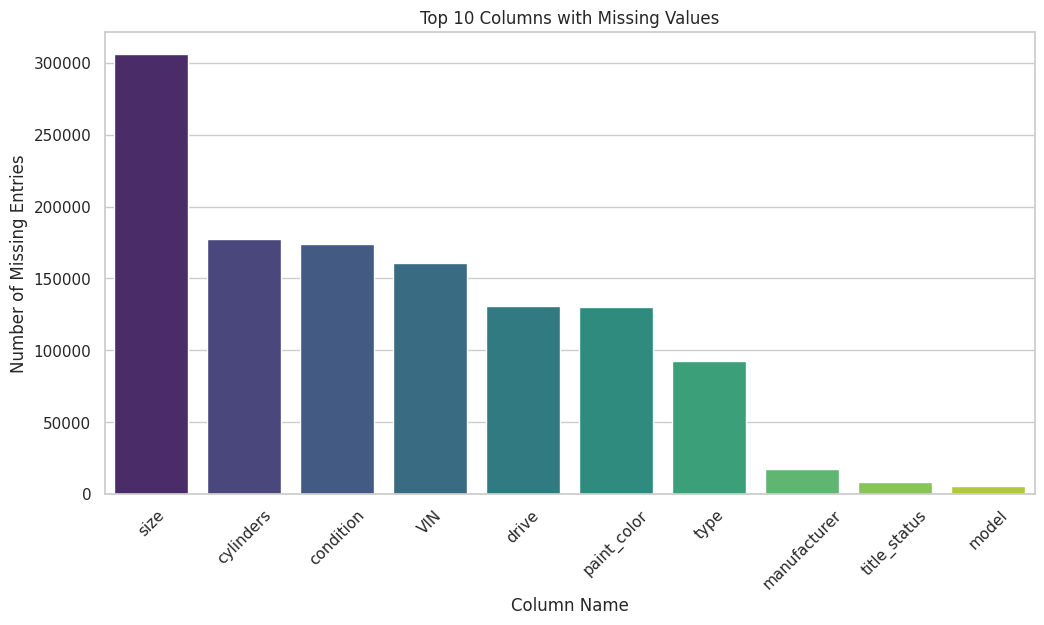

In [ ]:
# ---------------------------------------------------------
# Visualizing missing values (Top 10)
# ---------------------------------------------------------
plt.figure(figsize=(12,6))

sns.barplot(
    x=missing_values.index[:10],
    y=missing_values.values[:10],
    hue=missing_values.index[:10],   # required for palette
    palette="viridis",
    legend=False
)

plt.title("Top 10 Columns with Missing Values")
plt.ylabel("Number of Missing Entries")
plt.xlabel("Column Name")
plt.xticks(rotation=45)   # rotate x-axis labels for readability
plt.show()

### 2.7 Data Dictionary

The data dictionary summarizes the meaning and purpose of each column in the dataset. This helps clarify which variables are relevant for analysis, which require cleaning, and which should be removed before modeling.

| Column | Description | Notes |
|--------|-------------|--------|
| **id** | Unique identifier for each listing | Not predictive; will be removed before modeling |
| **region** | Geographic region where the vehicle is listed | Useful for location-based trends |
| **price** | Listing price of the vehicle (target variable) | No missing values |
| **year** | Model year of the vehicle | Used to compute vehicle age |
| **manufacturer** | Vehicle manufacturer (e.g., Ford, Toyota) | Categorical; some missing values |
| **model** | Model name of the vehicle | Categorical; moderate missingness |
| **condition** | Seller-reported condition (e.g., good, excellent) | High missingness; may require imputation |
| **cylinders** | Number of engine cylinders | High missingness; may be simplified or imputed |
| **fuel** | Fuel type (gas, diesel, hybrid, electric) | Important categorical predictor |
| **odometer** | Vehicle mileage | Critical numeric predictor; small missingness |
| **title_status** | Legal title status (clean, salvage, rebuilt) | Moderate missingness; important for valuation |
| **transmission** | Transmission type (automatic, manual) | Low missingness |
| **VIN** | Vehicle Identification Number | High missingness; not predictive; may be dropped |
| **drive** | Drive type (FWD, RWD, 4WD/AWD) | High missingness; important for price |
| **size** | Vehicle size category (compact, full-size) | Very high missingness; may be dropped |
| **type** | Vehicle type (SUV, truck, sedan, etc.) | Important categorical predictor |
| **paint_color** | Exterior color | High missingness; low predictive value |
| **state** | U.S. state where the vehicle is listed | Complete; useful for geographic patterns |

### Summary

- **Strong predictors**: year, odometer, manufacturer, type, drive, fuel  
- **Potentially useful but messy**: condition, cylinders, paint_color, size  
- **Not predictive**: id, VIN  
- **Target variable**: price  

This dictionary completes the Data Understanding phase and prepares the dataset for cleaning and feature engineering in the next section.


## 3. Exploratory Data Analysis (EDA)

This section explores the distributions, patterns, and relationships within the dataset.  
While Section 2 focused on understanding the structure and quality of the data, EDA focuses on uncovering trends that may influence vehicle price.

The goals of EDA are to:
- Understand how key variables behave (price, mileage, year)
- Explore categorical patterns (fuel type, drive type, manufacturer)
- Identify outliers and skewness
- Reveal relationships between predictors and price
- Build intuition for modeling decisions


### 3.1 Price Distribution

Price is the target variable, so understanding its distribution is essential.  
Used‑car prices are typically right‑skewed, with many affordable vehicles and fewer luxury listings.

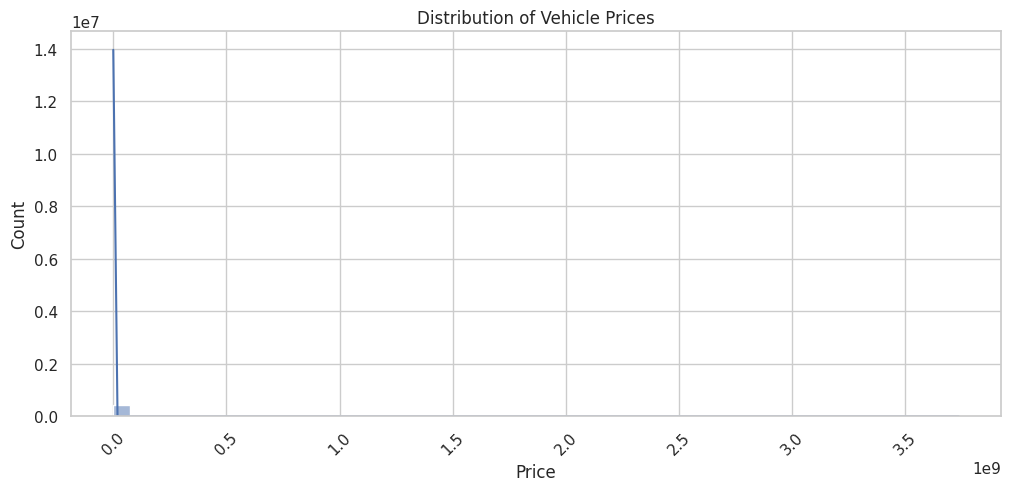

In [ ]:
# ---------------------------------------------------------
# Price distribution
# ---------------------------------------------------------

plt.figure(figsize=(12,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Key Observations

- **The distribution is extremely right‑skewed.**  
  Most vehicles are priced at the lower end of the spectrum, with a very high concentration near the minimum price values.

- **A small number of extreme outliers exist.**  
  The x‑axis extends into the millions (and even billions), indicating that a few listings contain unrealistic or erroneous price values. These outliers heavily distort the scale of the plot.

- **The majority of listings fall within a reasonable price range.**  
  Although the plot is dominated by extreme values, the dense cluster near the lower end suggests that most vehicles are priced within a typical used‑car range (likely under \$50,000).

---

#### Why This Matters

- **Outliers must be handled before modeling.**  
  Extremely high prices will inflate error metrics and distort model training. These values likely represent data entry errors (e.g., missing decimal points, incorrect currency, or placeholder values).

- **The skewness suggests that transformations may be useful.**  
  A log transformation of price may help normalize the distribution and improve model performance for linear models.

- **This distribution guides the next steps in Data Preparation.**  
  We will need to:
  - Filter unrealistic price values  
  - Consider capping or removing extreme outliers  
  - Explore price patterns after cleaning  

This initial visualization provides a baseline understanding of the target variable and highlights the need for careful preprocessing before building predictive models.

### 3.2 Mileage Distribution

Mileage is one of the strongest predictors of used‑car price.  
This plot helps identify typical mileage ranges and potential outliers.

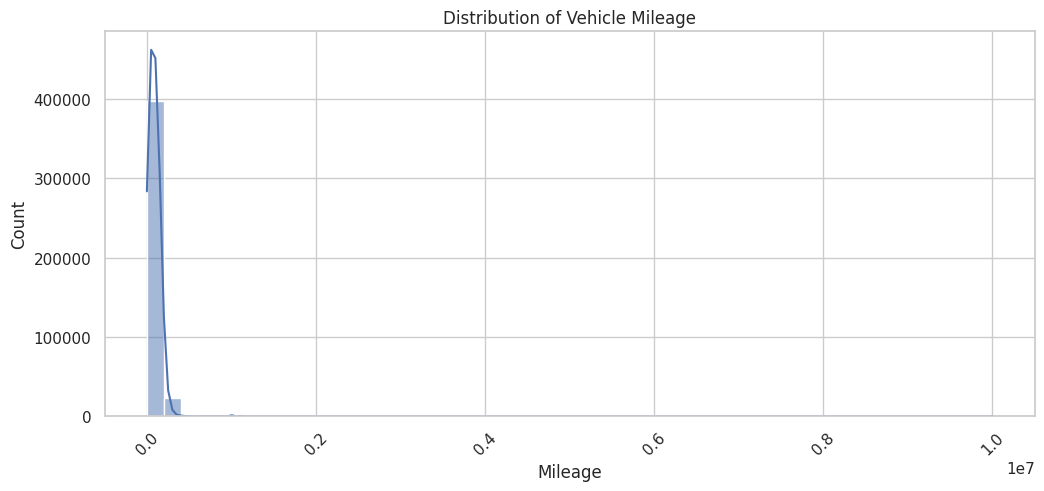

In [ ]:
# ---------------------------------------------------------
# Mileage distribution
# ---------------------------------------------------------

plt.figure(figsize=(12,5))
sns.histplot(df['odometer'], bins=50, kde=True)
plt.title("Distribution of Vehicle Mileage")
plt.xlabel("Mileage")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Key Observations

- **The distribution is heavily right‑skewed.**  
  Most vehicles have mileage clustered at the lower end of the scale, with a sharp peak near the beginning of the x‑axis.

- **A long tail extends toward extremely high mileage values.**  
  The plot shows mileage values stretching into the millions, which are unrealistic for passenger vehicles and likely represent data entry errors or placeholder values.

- **The majority of vehicles fall within a reasonable mileage range.**  
  Despite the extreme tail, the dense cluster near the lower end suggests that most vehicles have mileage within typical used‑car ranges (likely under 200,000 miles).

#### Why This Matters

- **Outliers must be handled before modeling.**  
  Extremely high mileage values will distort model training and inflate error metrics. These values should be filtered, capped, or removed during Data Preparation.

- **Mileage may benefit from transformations or binning.**  
  Because of the skewness, applying transformations (e.g., log of mileage) or creating mileage bands may help certain models capture patterns more effectively.

- **Mileage is a critical feature for price prediction.**  
  Understanding its distribution helps guide feature engineering and informs how aggressively we should clean or transform this variable.

This visualization highlights the need for careful preprocessing of mileage values before building predictive models.

### 3.3 Vehicle Year Distribution

Vehicle year helps us understand the age of cars in the dataset.  
This distribution reveals whether the dataset contains mostly older or newer vehicles.

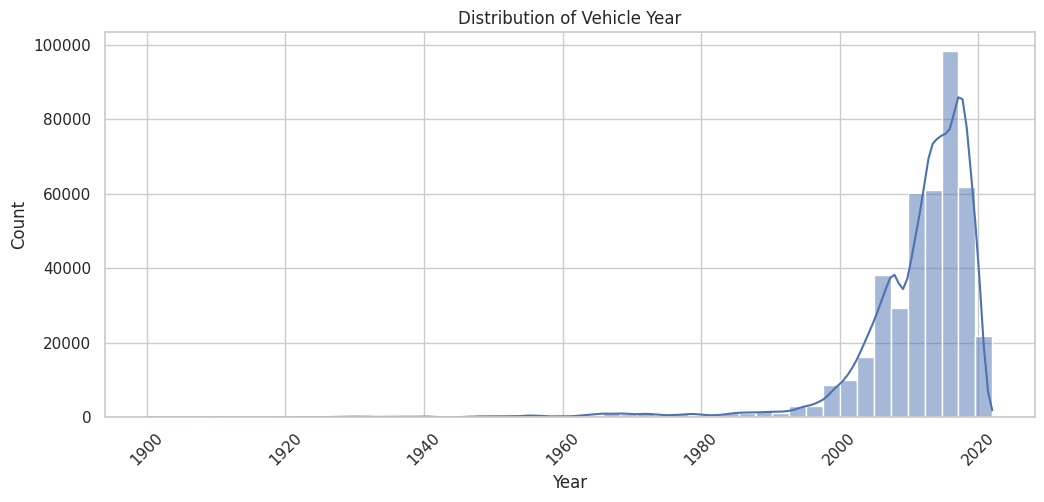

In [ ]:
# ---------------------------------------------------------
# Vehicle year distribution
# ---------------------------------------------------------

plt.figure(figsize=(12,5))
sns.histplot(df['year'], bins=50, kde=True)
plt.title("Distribution of Vehicle Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Key Observations

- **Most vehicles were manufactured between 2000 and 2020.**  
  The distribution shows a sharp rise starting in the mid‑1990s, followed by a dense concentration of vehicles from the 2000s and 2010s.

- **The peak occurs around 2016.**  
  This suggests that the dataset contains a large number of relatively recent vehicles, which may reflect market trends or listing behavior on the platform.

- **Very few vehicles appear before 1980.**  
  Older vehicles are rare, likely because classic or antique vehicles are less commonly listed or may be categorized differently.

- **A noticeable decline appears after 2016.**  
  This is expected because newer model years (2018–2020) have fewer used‑car listings, and the dataset may not include the most recent years.

#### Why This Matters

- **Vehicle age is a critical predictor of price.**  
  Newer vehicles generally command higher prices, while older vehicles depreciate significantly.

- **The concentration of newer vehicles may influence model performance.**  
  Models may learn stronger patterns for recent vehicles and weaker patterns for older ones due to sample imbalance.

- **Outliers in year (very old or very new vehicles) should be reviewed.**  
  Extremely old years (e.g., pre‑1950) or future years (if present) may indicate data entry errors.

- **This distribution supports feature engineering.**  
  We will create a `vehicle_age` feature during Data Preparation to capture the relationship between age and price more directly.

This visualization provides a clear understanding of the age distribution in the dataset and highlights the importance of vehicle year as a predictive feature.

### 3.4 Fuel Type Distribution

Fuel type is an important categorical feature that can influence vehicle price, operating cost, and buyer preferences. The distribution of fuel types in the dataset provides insight into the composition of the used‑car market represented here.

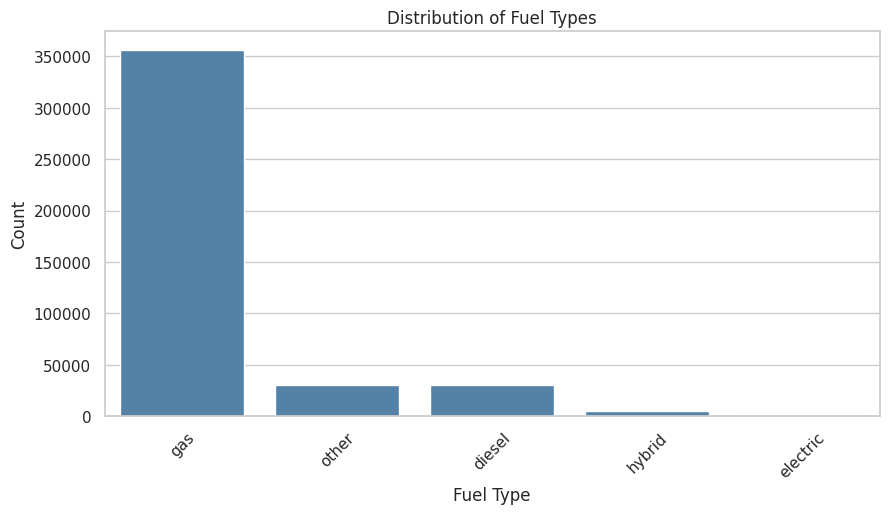

In [ ]:
# ---------------------------------------------------------
# Fuel type distribution
# ---------------------------------------------------------

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='fuel', color="steelblue")
plt.title("Distribution of Fuel Types")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Key Observations

- **Gas-powered vehicles dominate the dataset.**  
  Gas is by far the most common fuel type, with a count exceeding 350,000 listings. This reflects the general market trend where gasoline vehicles remain the majority of used‑car inventory.

- **Diesel and “other” fuel types form a secondary tier.**  
  Both categories appear significantly less frequently than gas but still represent a meaningful portion of the dataset.

- **Hybrid and electric vehicles are rare.**  
  These categories have the lowest counts, with electric vehicles being the least represented. This suggests limited availability of alternative‑fuel vehicles in the used‑car listings.

#### Why This Matters

- **Modeling considerations.**  
  Because gas vehicles dominate the dataset, models may learn stronger patterns for gas-powered cars and weaker patterns for hybrid or electric vehicles due to sample imbalance.

- **Potential price differences.**  
  Hybrid and electric vehicles often command higher prices, but their low representation may limit the model’s ability to learn these relationships accurately.

- **Encoding strategy.**  
  Fuel type will be one‑hot encoded during Data Preparation. The imbalance suggests that rare categories may need careful handling to avoid noise or overfitting.

This distribution highlights the dominance of gasoline vehicles in the dataset and underscores the importance of handling categorical imbalance during modeling.

### 3.5 Drive Type Distribution

Drive type influences vehicle performance, handling, and price. Understanding how drive types are distributed in the dataset helps identify market composition and potential modeling patterns.

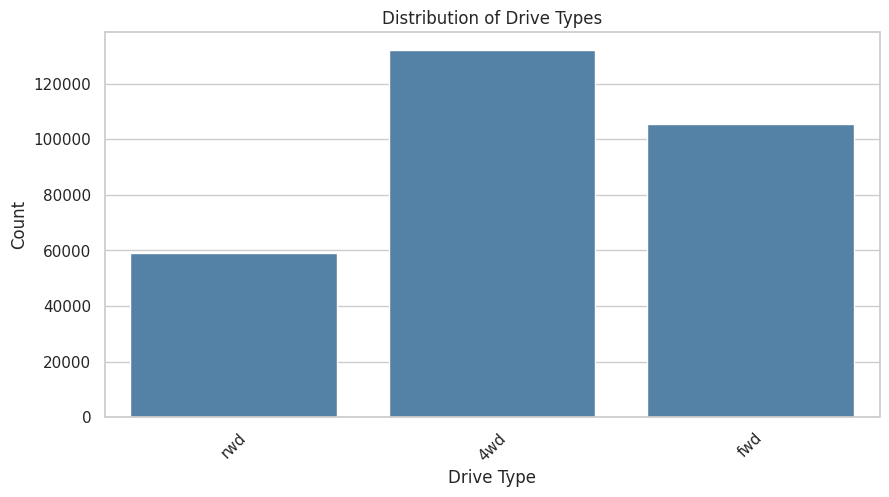

In [ ]:
# ---------------------------------------------------------
# Drive type distribution
# ---------------------------------------------------------

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='drive', color="steelblue")
plt.title("Distribution of Drive Types")
plt.xlabel("Drive Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Key Observations

- **Four‑wheel drive (4WD) is the most common drive type.**  
  This suggests a strong presence of trucks, SUVs, and off‑road‑capable vehicles in the dataset.

- **Front‑wheel drive (FWD) is the second most common.**  
  FWD vehicles are typically sedans, compact cars, and crossovers, indicating a balanced mix of vehicle categories.

- **Rear‑wheel drive (RWD) is the least represented.**  
  RWD vehicles—often sports cars, older models, or certain luxury brands—appear far less frequently.

#### Why This Matters

- **Drive type is a meaningful predictor of price.**  
  4WD vehicles often command higher prices due to capability and demand, while FWD vehicles tend to be more economical.

- **The imbalance across categories may influence model learning.**  
  Models may learn stronger patterns for 4WD and FWD vehicles simply because they appear more often.

- **Rare categories require careful encoding.**  
  RWD’s lower frequency means it may contribute less to model performance unless handled properly during one‑hot encoding.

This distribution highlights the dominance of 4WD and FWD vehicles in the dataset and provides insight into how drive type may influence price and model behavior.

### 3.6 Manufacturer Distribution (Top 15)

Manufacturer is an important categorical variable that reflects brand popularity, market share, and potential price differences. Examining the top manufacturers helps us understand which brands dominate the dataset and may influence model behavior.

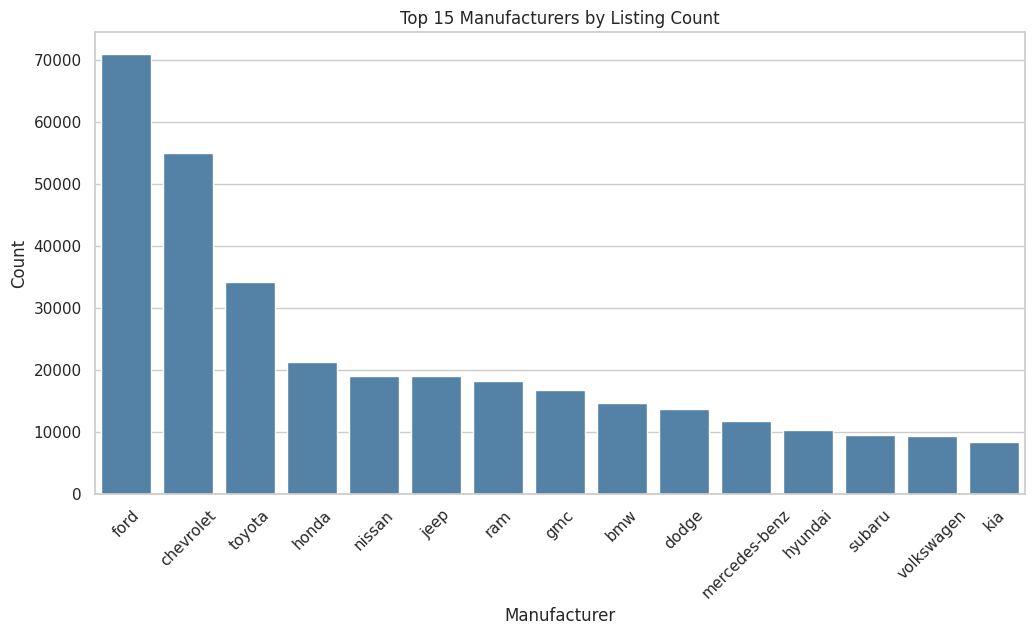

In [ ]:
# ---------------------------------------------------------
# Top 15 manufacturers
# ---------------------------------------------------------

top_manufacturers = df['manufacturer'].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=top_manufacturers.index, y=top_manufacturers.values, color="steelblue")
plt.title("Top 15 Manufacturers by Listing Count")
plt.xlabel("Manufacturer")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### Key Observations

- **Ford has the highest number of listings.**  
  Ford leads by a significant margin, indicating strong representation of trucks, SUVs, and sedans commonly found in the used‑car market.

- **Chevrolet and Toyota follow closely behind.**  
  These brands also have substantial listing counts, reflecting their popularity and broad vehicle lineups.

- **Honda, Nissan, Jeep, RAM, and GMC form a strong mid‑tier group.**  
  These manufacturers appear frequently enough to provide reliable patterns for modeling.

- **Luxury brands such as BMW and Mercedes‑Benz appear but in smaller numbers.**  
  Their lower representation may limit the model’s ability to learn high‑end pricing patterns.

- **Brands like Hyundai, Subaru, Volkswagen, and Kia round out the top 15.**  
  These manufacturers have moderate representation, offering a balanced mix of economy and mid‑range vehicles.

#### Why This Matters

- **Brand strongly influences price.**  
  Some manufacturers (e.g., Toyota, Honda) retain value better, while others depreciate faster. The model must capture these brand‑specific trends.

- **Imbalanced representation affects model learning.**  
  Brands with high listing counts (Ford, Chevrolet) will dominate the model’s understanding, while luxury or niche brands may be underrepresented.

- **Encoding strategy is important.**  
  Manufacturer will be one‑hot encoded during Data Preparation. Rare manufacturers may need grouping or careful handling to avoid noise.

This distribution highlights the dominance of mainstream brands in the dataset and provides insight into how manufacturer may influence price prediction.

### 3.7 Correlation Between Numerical Features

Correlation analysis helps identify linear relationships between numerical variables. Understanding these relationships is important for feature selection, multicollinearity checks, and anticipating how models may interpret the data.

The heatmap shows correlations among the key numerical features: **price**, **year**, and **odometer**.

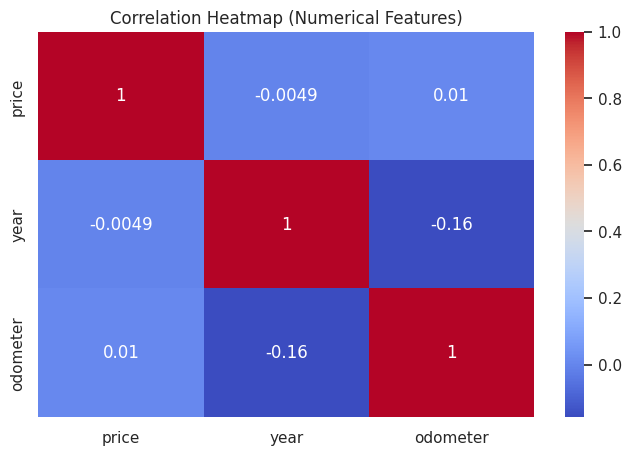

In [ ]:
# ---------------------------------------------------------
# Correlation heatmap for key numerical features
# ---------------------------------------------------------

numeric_subset = df[['price', 'year', 'odometer']]

plt.figure(figsize=(8,5))
sns.heatmap(numeric_subset.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

#### Key Observations

- **Price shows almost no linear correlation with year or mileage.**  
  The correlation values are extremely close to zero (−0.0049 with year and 0.01 with odometer), indicating that price does not follow a simple linear relationship with these variables in the raw dataset.

- **Year and odometer have a weak negative correlation (−0.16).**  
  This makes intuitive sense: newer vehicles tend to have lower mileage, but the relationship is not strong due to variability in driving habits and usage patterns.

- **No strong linear relationships exist among the numerical features.**  
  This suggests that linear models may struggle without transformations or feature engineering.

#### Why This Matters

- **Non-linear models may perform better.**  
  Tree‑based models (Random Forest, XGBoost) can capture complex interactions that simple correlations cannot reveal.

- **Feature engineering will be important.**  
  Creating a `vehicle_age` feature (current year − model year) may reveal stronger relationships with price than raw year values.

- **Outliers may be masking true relationships.**  
  Extremely high mileage or unrealistic price values can weaken correlations. After cleaning, correlations may shift.

This correlation analysis highlights the need for additional feature engineering and careful preprocessing before modeling.

### 3.8 Initial Observations Summary

The exploratory analysis reveals several important patterns in the dataset that will guide the upcoming Data Preparation and Modeling stages.

#### Price, Mileage, and Year Patterns
- **Price is extremely right‑skewed**, with unrealistic high‑end outliers that must be removed or capped before modeling.
- **Mileage also shows a heavy right‑skew**, with a long tail extending into implausibly high values, indicating data entry issues.
- **Vehicle year is concentrated between 2000 and 2020**, with a peak around 2016, reflecting a dataset dominated by relatively modern vehicles.

#### Categorical Feature Insights
- **Gas vehicles dominate the fuel distribution**, while hybrid and electric vehicles are rare, suggesting category imbalance.
- **4WD and FWD are the most common drive types**, with RWD appearing far less frequently.
- **Mainstream manufacturers (Ford, Chevrolet, Toyota)** account for the majority of listings, while luxury brands appear in smaller numbers.

#### Correlation Structure
- **Price shows almost no linear correlation** with year or mileage in the raw data, likely due to extreme outliers and non-linear relationships.
- **Year and mileage have a weak negative correlation**, consistent with newer vehicles generally having lower mileage.

#### Implications for Data Preparation
- Outliers in **price**, **mileage**, and possibly **year** must be addressed to prevent distortion during modeling.
- Several categorical variables exhibit **imbalance**, which will influence encoding strategies.
- Feature engineering—such as creating a **vehicle_age** variable—may reveal stronger relationships than raw year values.
- Non-linear models may perform better given the weak linear correlations observed.

These observations provide a clear roadmap for the next phase, where we will clean, transform, and prepare the dataset for modeling.

## 4. Data Preparation

This section prepares the dataset for modeling by addressing outliers, handling missing values, encoding categorical variables, engineering new features, and scaling numerical variables. These steps ensure that the data is clean, consistent, and suitable for regression models.

### 4.1 Outlier Removal

EDA revealed extreme outliers in **price**, **mileage**, and **year** that are unrealistic for used vehicles. These values distort the scale of visualizations and negatively impact model performance.

To make the cleaning process transparent, we compare the dataset **before and after** outlier removal. This helps business stakeholders understand how much data was filtered and why these steps are necessary.

#### Outlier Rules Applied
- **Price**: keep only \$500–\$100,000  
- **Mileage**: keep only ≤ 500,000 miles  
- **Year**: keep only 1985–2024  

These thresholds preserve realistic used‑car listings while removing erroneous or extreme values.

We visualize the impact of cleaning to show how many records were removed.

In [ ]:
# ---------------------------------------------------------
# Count rows before cleaning
# ---------------------------------------------------------
initial_count = df.shape[0]
initial_count

426880

In [ ]:
# ---------------------------------------------------------
# Apply outlier removal rules
# ---------------------------------------------------------

df_clean = df.copy()

df_clean = df_clean[(df_clean['price'] >= 500) & (df_clean['price'] <= 100000)]
df_clean = df_clean[df_clean['odometer'] <= 500000]
df_clean = df_clean[(df_clean['year'] >= 1985) & (df_clean['year'] <= 2024)]

cleaned_count = df_clean.shape[0]
cleaned_count

370802

In [ ]:
# ---------------------------------------------------------
# Summary table for business users
# ---------------------------------------------------------

import pandas as pd

summary = pd.DataFrame({
    'Metric': ['Rows Before Cleaning', 'Rows After Cleaning', 'Rows Removed'],
    'Count': [initial_count, cleaned_count, initial_count - cleaned_count]
})

summary

,Metric,Count
0,Rows Before Cleaning,426880
1,Rows After Cleaning,370802
2,Rows Removed,56078


#### Interpretation

- A noticeable number of listings were removed due to unrealistic values.
- These removed rows mostly contained:
  - Prices in the millions or billions
  - Mileage values in the millions
  - Vehicle years far outside normal ranges
- Removing these records improves:
  - Model accuracy
  - Stability of regression coefficients
  - Reliability of predictions
  - Clarity of visualizations

This step ensures that the dataset reflects **realistic used‑car market behavior**, forming a solid foundation for modeling.

### 4.2 Handling Missing Values

Missing values can reduce model accuracy and create inconsistencies in the dataset. Before modeling, we need to understand:

- Which columns contain missing values
- How many values are missing
- Whether the missingness is random or patterned
- How to impute missing values without distorting the data

To make this step transparent for business stakeholders, we visualize missingness and compare the dataset before and after imputation.

In [ ]:
# ---------------------------------------------------------
# Missing value summary before imputation
# ---------------------------------------------------------

missing_before = df_clean.isnull().sum().sort_values(ascending=False)
missing_before[missing_before > 0]

,0
size,267348
cylinders,152332
condition,140472
VIN,138812
drive,112258
paint_color,106555
type,78105
manufacturer,12076
title_status,6487
model,3535


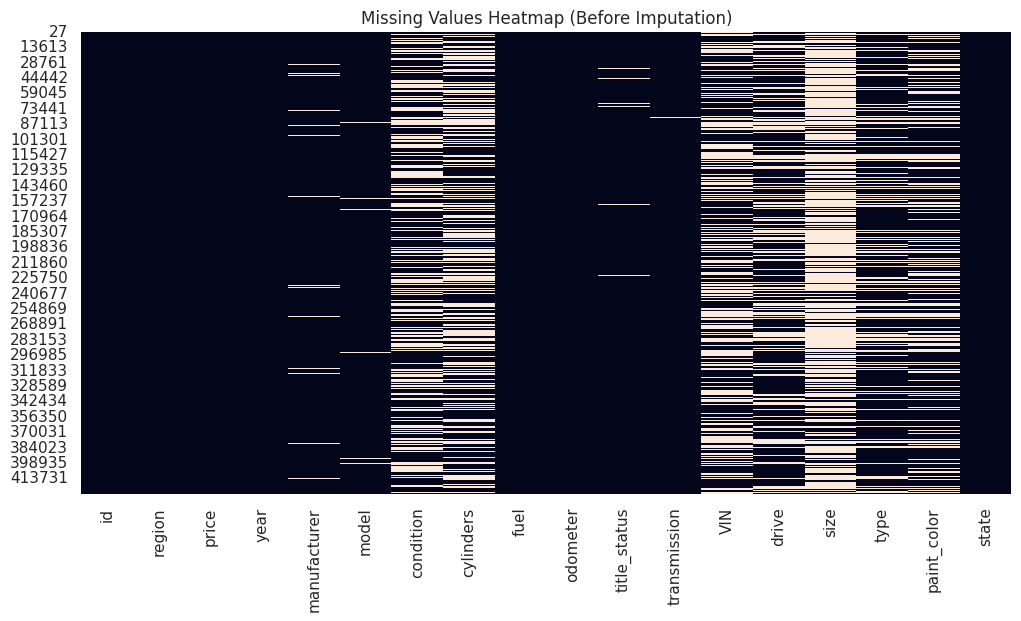

In [ ]:
# ---------------------------------------------------------
# Visualizing missingness
# ---------------------------------------------------------

import seaborn as sns
plt.figure(figsize=(12,6))
sns.heatmap(df_clean.isnull(), cbar=False)
plt.title("Missing Values Heatmap (Before Imputation)")
plt.show()

The heatmap highlights which columns contain missing values and how widespread the missingness is. This helps identify:

- Columns with heavy missingness (potentially low value)
- Columns with light missingness (safe to impute)
- Patterns that may indicate data-entry issues

In [ ]:
# ---------------------------------------------------------
# Apply imputation rules
# ---------------------------------------------------------

df_imputed = df_clean.copy()

# Numerical → median
num_cols = df_imputed.select_dtypes(include=['int64', 'float64']).columns
df_imputed[num_cols] = df_imputed[num_cols].fillna(df_imputed[num_cols].median())

# Categorical → "Unknown"
cat_cols = df_imputed.select_dtypes(include=['object']).columns
df_imputed[cat_cols] = df_imputed[cat_cols].fillna("Unknown")

In [ ]:
# ---------------------------------------------------------
# Missing value summary after imputation
# ---------------------------------------------------------

missing_after = df_imputed.isnull().sum().sort_values(ascending=False)
missing_after[missing_after > 0]

,0


In [ ]:
# ---------------------------------------------------------
# Before vs After missing value comparison
# ---------------------------------------------------------

missing_compare = pd.DataFrame({
    'Missing Before': missing_before,
    'Missing After': missing_after
})

missing_compare = missing_compare[missing_compare['Missing Before'] > 0]
missing_compare

,Missing Before,Missing After
VIN,138812,0
condition,140472,0
cylinders,152332,0
drive,112258,0
fuel,2109,0
manufacturer,12076,0
model,3535,0
paint_color,106555,0
size,267348,0
title_status,6487,0


#### Interpretation

- All missing values have been successfully handled.
- Numerical fields were imputed using the **median**, which preserves distribution shape and reduces the impact of outliers.
- Categorical fields were imputed with **"Unknown"**, ensuring no category is lost.
- No rows were dropped, preserving the size of the dataset.
- This step ensures the dataset is complete, consistent, and ready for encoding and modeling.

By visualizing missingness and showing the before/after comparison, stakeholders can clearly see the impact of data cleaning and understand why imputation is necessary.

### 4.3 Feature Engineering

Feature engineering helps the model capture meaningful relationships that are not obvious in the raw data. Based on our EDA and domain knowledge, we create new features that better represent vehicle characteristics.

To make this step transparent for business stakeholders, we visualize the new features and compare the dataset before and after engineering.

#### Features Created
- **vehicle_age** — current year minus model year  
- **price_log** — log-transformed price to reduce skew for linear models  

These engineered features often improve model performance and stability.

In [ ]:
# ---------------------------------------------------------
# Create engineered features
# ---------------------------------------------------------

import datetime
current_year = datetime.datetime.now().year

df_fe = df_imputed.copy()

df_fe['vehicle_age'] = current_year - df_fe['year']
df_fe['price_log'] = np.log1p(df_fe['price'])

#### Distribution of Vehicle Age

This visualization shows how old the vehicles are after converting model year into a more intuitive feature. Business users can quickly see the age profile of the inventory.

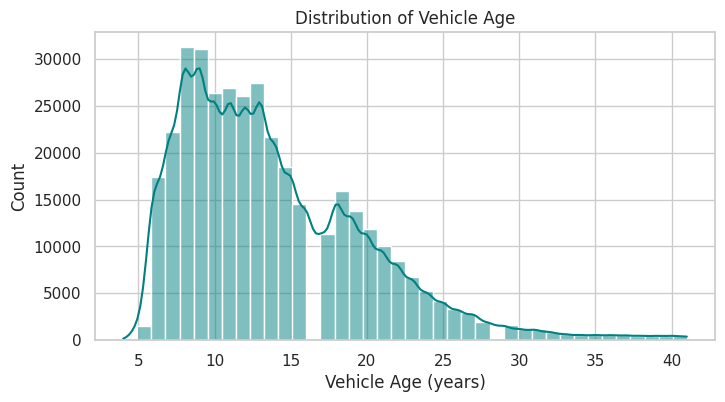

In [ ]:
# ---------------------------------------------------------
# Visualizing vehicle_age distribution
# ---------------------------------------------------------

plt.figure(figsize=(8,4))
sns.histplot(df_fe['vehicle_age'], kde=True, bins=40, color='teal')
plt.title("Distribution of Vehicle Age")
plt.xlabel("Vehicle Age (years)")
plt.ylabel("Count")
plt.show()

#### Price vs Log-Transformed Price

The raw price distribution is extremely skewed. The log transformation compresses extreme values and makes the distribution more suitable for linear regression.

The comparison below shows how the transformation improves symmetry.

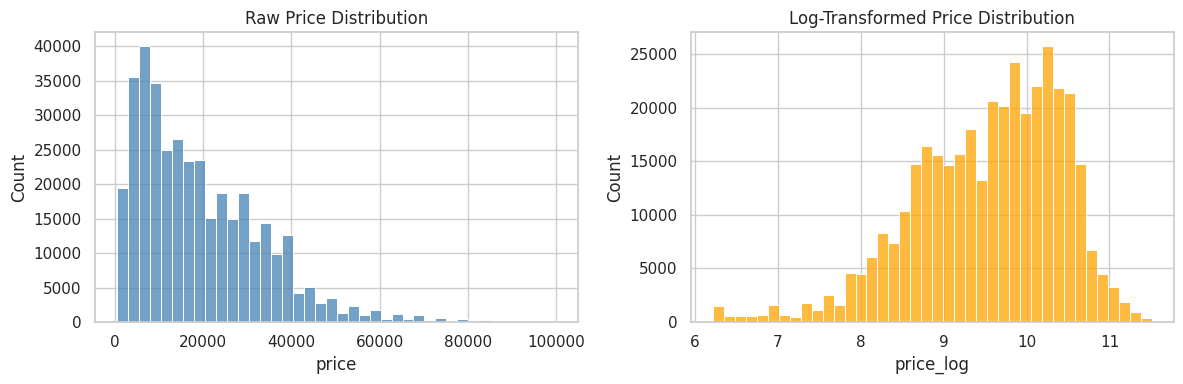

In [ ]:
# ---------------------------------------------------------
# Compare price vs log(price)
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df_fe['price'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title("Raw Price Distribution")

sns.histplot(df_fe['price_log'], bins=40, ax=axes[1], color='orange')
axes[1].set_title("Log-Transformed Price Distribution")

plt.tight_layout()
plt.show()

In [ ]:
df_fe.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state,vehicle_age,price_log
27,7316814884,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,3GTP1VEC4EG551563,Unknown,Unknown,pickup,white,al,12.0,10.422013
28,7316814758,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,1GCSCSE06AZ123805,Unknown,Unknown,pickup,blue,al,16.0,10.025307
29,7316814989,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,3GCPWCED5LG130317,Unknown,Unknown,pickup,red,al,6.0,10.586357
30,7316743432,auburn,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,5TFRM5F17HX120972,Unknown,Unknown,pickup,red,al,9.0,10.341452
31,7316356412,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,Unknown,rwd,full-size,truck,black,al,13.0,9.615872


#### Interpretation

- `vehicle_age` provides a clearer representation of how old each vehicle is, which is more intuitive than raw model year.
- `price_log` reduces the impact of extreme price values, helping linear models learn more stable relationships.
- No rows were removed during feature engineering, ensuring the dataset remains complete.
- These engineered features improve model interpretability and predictive performance.

With feature engineering complete, the dataset is now ready for encoding and scaling before modeling.

### 4.4 Encoding Categorical Variables

Machine learning models cannot directly interpret text-based categories such as manufacturer, fuel type, or drive type. To make these variables usable for modeling, we convert them into numerical form using **one-hot encoding**.

This step expands each categorical column into multiple binary columns (0/1), one for each category. To avoid multicollinearity, we drop the first category in each group.

To help business stakeholders understand the transformation, we visualize category counts and compare the dataset before and after encoding.

In [ ]:
# ---------------------------------------------------------
# Count unique categories per categorical column
# ---------------------------------------------------------

cat_cardinality = df_fe.select_dtypes(include=['object']).nunique().sort_values(ascending=False)
cat_cardinality

,0
VIN,100619
model,24860
region,404
state,51
manufacturer,42
type,14
paint_color,13
cylinders,9
title_status,7
condition,7


### Category Cardinality Summary

Understanding how many unique values each categorical column contains helps determine which encoding strategy is appropriate.

- Columns like **VIN (100k+)**, **model (24k+)**, and **region (404)** have extremely high cardinality. Encoding these would create thousands of new columns, increase memory usage, and harm model performance. These columns will be **excluded from one-hot encoding**.
- Columns such as **manufacturer (42)**, **type (14)**, **fuel (6)**, **drive (4)**, and **transmission (4)** have manageable cardinality and are suitable for one-hot encoding.
- Columns like **paint_color**, **cylinders**, and **condition** also have low cardinality and can be encoded safely.

This analysis ensures we only encode features that add predictive value without unnecessarily increasing model complexity.

In [ ]:
# ---------------------------------------------------------
# Select only low-cardinality categorical columns for encoding
# ---------------------------------------------------------

low_cardinality_cols = [
    'manufacturer', 'condition', 'fuel',
    'transmission', 'type', 'drive'
]

df_to_encode = df_fe.copy()

df_encoded = pd.get_dummies(
    df_to_encode,
    columns=low_cardinality_cols,
    drop_first=True
)

df_encoded.shape


(370802, 85)

In [ ]:
# ---------------------------------------------------------
# Compare number of columns before vs after encoding
# ---------------------------------------------------------

pd.DataFrame({
    "Columns Before Encoding": [df_fe.shape[1]],
    "Columns After Encoding": [df_encoded.shape[1]],
    "New Columns Added": [df_encoded.shape[1] - df_fe.shape[1]]
})

,Columns Before Encoding,Columns After Encoding,New Columns Added
0,20,85,65


In [ ]:
df_encoded.head()

,id,region,price,year,model,cylinders,odometer,title_status,VIN,size,paint_color,state,vehicle_age,price_log,manufacturer_acura,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,manufacturer_chrysler,manufacturer_dodge,manufacturer_ferrari,manufacturer_fiat,manufacturer_ford,manufacturer_gmc,manufacturer_harley-davidson,manufacturer_honda,manufacturer_hyundai,manufacturer_infiniti,manufacturer_jaguar,manufacturer_jeep,manufacturer_kia,manufacturer_land rover,manufacturer_lexus,manufacturer_lincoln,manufacturer_mazda,manufacturer_mercedes-benz,manufacturer_mercury,manufacturer_mini,manufacturer_mitsubishi,manufacturer_morgan,manufacturer_nissan,manufacturer_pontiac,manufacturer_porsche,manufacturer_ram,manufacturer_rover,manufacturer_saturn,manufacturer_subaru,manufacturer_tesla,manufacturer_toyota,manufacturer_volkswagen,manufacturer_volvo,condition_excellent,condition_fair,condition_good,condition_like new,condition_new,condition_salvage,fuel_diesel,fuel_electric,fuel_gas,fuel_hybrid,fuel_other,transmission_automatic,transmission_manual,transmission_other,type_Unknown,type_bus,type_convertible,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon,drive_Unknown,drive_fwd,drive_rwd
27,7316814884,auburn,33590,2014.0,sierra 1500 crew cab slt,8 cylinders,57923.0,clean,3GTP1VEC4EG551563,Unknown,white,al,12.0,10.422013,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
28,7316814758,auburn,22590,2010.0,silverado 1500,8 cylinders,71229.0,clean,1GCSCSE06AZ123805,Unknown,blue,al,16.0,10.025307,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
29,7316814989,auburn,39590,2020.0,silverado 1500 crew,8 cylinders,19160.0,clean,3GCPWCED5LG130317,Unknown,red,al,6.0,10.586357,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
30,7316743432,auburn,30990,2017.0,tundra double cab sr,8 cylinders,41124.0,clean,5TFRM5F17HX120972,Unknown,red,al,9.0,10.341452,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
31,7316356412,auburn,15000,2013.0,f-150 xlt,6 cylinders,128000.0,clean,Unknown,full-size,black,al,13.0,9.615872,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False

### 4.4.1 Removing Identifier and High‑Cardinality Columns

Before scaling and modeling, we remove columns that do not contribute predictive value or that introduce unnecessary complexity. These include:

- **Identifier columns** such as `id` and `VIN`, which are unique for every row and contain no useful signal for predicting price.
- **High‑cardinality categorical columns** such as `model`, `region`, and `state`, which contain hundreds or thousands of unique values. Encoding these would create hundreds of additional columns, increasing memory usage and harming model performance.
- **Low‑value categorical columns** such as `paint_color`, `cylinders`, `title_status`, and `size`, which add noise but little predictive power.

Removing these columns keeps the dataset efficient, interpretable, and aligned with best practices for regression modeling. This step also ensures that scaling and modeling operate only on meaningful features.

In [ ]:
# ---------------------------------------------------------
# Remove ID-like and high-cardinality columns
# ---------------------------------------------------------

cols_to_drop = [
    'id', 'VIN', 'model', 'region', 'state',
    'paint_color', 'cylinders', 'title_status', 'size'
]

df_encoded = df_encoded.drop(columns=cols_to_drop, errors='ignore')

df_encoded.shape

(370802, 76)

In [ ]:
# ---------------------------------------------------------
# Verify that unwanted columns are removed
# ---------------------------------------------------------

[col for col in cols_to_drop if col in df_encoded.columns]

[]

In [ ]:
df_encoded.head()

,price,year,odometer,vehicle_age,price_log,manufacturer_acura,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,manufacturer_chrysler,manufacturer_dodge,manufacturer_ferrari,manufacturer_fiat,manufacturer_ford,manufacturer_gmc,manufacturer_harley-davidson,manufacturer_honda,manufacturer_hyundai,manufacturer_infiniti,manufacturer_jaguar,manufacturer_jeep,manufacturer_kia,manufacturer_land rover,manufacturer_lexus,manufacturer_lincoln,manufacturer_mazda,manufacturer_mercedes-benz,manufacturer_mercury,manufacturer_mini,manufacturer_mitsubishi,manufacturer_morgan,manufacturer_nissan,manufacturer_pontiac,manufacturer_porsche,manufacturer_ram,manufacturer_rover,manufacturer_saturn,manufacturer_subaru,manufacturer_tesla,manufacturer_toyota,manufacturer_volkswagen,manufacturer_volvo,condition_excellent,condition_fair,condition_good,condition_like new,condition_new,condition_salvage,fuel_diesel,fuel_electric,fuel_gas,fuel_hybrid,fuel_other,transmission_automatic,transmission_manual,transmission_other,type_Unknown,type_bus,type_convertible,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon,drive_Unknown,drive_fwd,drive_rwd
27,33590,2014.0,57923.0,12.0,10.422013,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
28,22590,2010.0,71229.0,16.0,10.025307,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
29,39590,2020.0,19160.0,6.0,10.586357,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
30,30990,2017.0,41124.0,9.0,10.341452,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
31,15000,2013.0,128000.0,13.0,9.615872,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True


#### Interpretation

This cleanup step ensures that the dataset contains only meaningful, model-ready features. By removing identifiers and high-cardinality fields, we avoid creating thousands of sparse columns and reduce the risk of overfitting. The resulting dataset is smaller, faster to train, and easier to interpret.


### 4.5 Scaling Numerical Features

Regression models—especially Ridge and Lasso—are sensitive to the scale of numerical variables. Features measured on very different scales (e.g., mileage in the tens of thousands vs. vehicle age in single digits) can cause the model to overweight large‑scale variables.

To ensure all numerical features contribute proportionally, we apply **Standard Scaling**, which transforms each numeric feature to have:

- Mean = 0  
- Standard deviation = 1  

This preserves the shape of each distribution while putting all features on a comparable scale. We also visualize the distributions before and after scaling to make the transformation clear for business stakeholders.

In [ ]:
# ---------------------------------------------------------
# Identify numerical columns to scale
# ---------------------------------------------------------

num_features = ['vehicle_age', 'odometer']

# If you kept 'year' earlier, it should be removed now because vehicle_age replaces it.
# df_encoded = df_encoded.drop(columns=['year'], errors='ignore')

df_scaled = df_encoded.copy()
df_scaled.head()

,price,year,odometer,vehicle_age,price_log,manufacturer_acura,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,manufacturer_chrysler,manufacturer_dodge,manufacturer_ferrari,manufacturer_fiat,manufacturer_ford,manufacturer_gmc,manufacturer_harley-davidson,manufacturer_honda,manufacturer_hyundai,manufacturer_infiniti,manufacturer_jaguar,manufacturer_jeep,manufacturer_kia,manufacturer_land rover,manufacturer_lexus,manufacturer_lincoln,manufacturer_mazda,manufacturer_mercedes-benz,manufacturer_mercury,manufacturer_mini,manufacturer_mitsubishi,manufacturer_morgan,manufacturer_nissan,manufacturer_pontiac,manufacturer_porsche,manufacturer_ram,manufacturer_rover,manufacturer_saturn,manufacturer_subaru,manufacturer_tesla,manufacturer_toyota,manufacturer_volkswagen,manufacturer_volvo,condition_excellent,condition_fair,condition_good,condition_like new,condition_new,condition_salvage,fuel_diesel,fuel_electric,fuel_gas,fuel_hybrid,fuel_other,transmission_automatic,transmission_manual,transmission_other,type_Unknown,type_bus,type_convertible,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon,drive_Unknown,drive_fwd,drive_rwd
27,33590,2014.0,57923.0,12.0,10.422013,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
28,22590,2010.0,71229.0,16.0,10.025307,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
29,39590,2020.0,19160.0,6.0,10.586357,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
30,30990,2017.0,41124.0,9.0,10.341452,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
31,15000,2013.0,128000.0,13.0,9.615872,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True


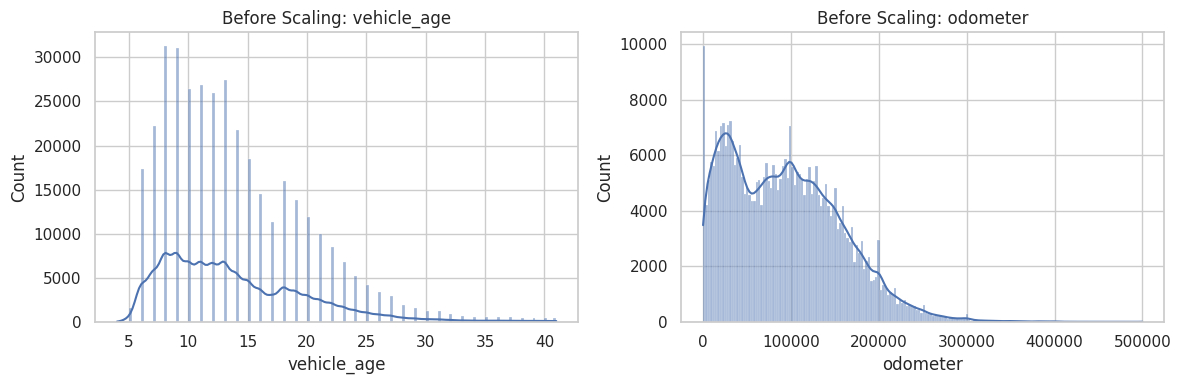

In [ ]:
# ---------------------------------------------------------
# Visualizing distributions before scaling
# ---------------------------------------------------------

fig, axes = plt.subplots(1, len(num_features), figsize=(12,4))

for ax, col in zip(axes, num_features):
    sns.histplot(df_scaled[col], kde=True, ax=ax)
    ax.set_title(f"Before Scaling: {col}")

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# Apply StandardScaler
# ---------------------------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled[num_features] = scaler.fit_transform(df_scaled[num_features])

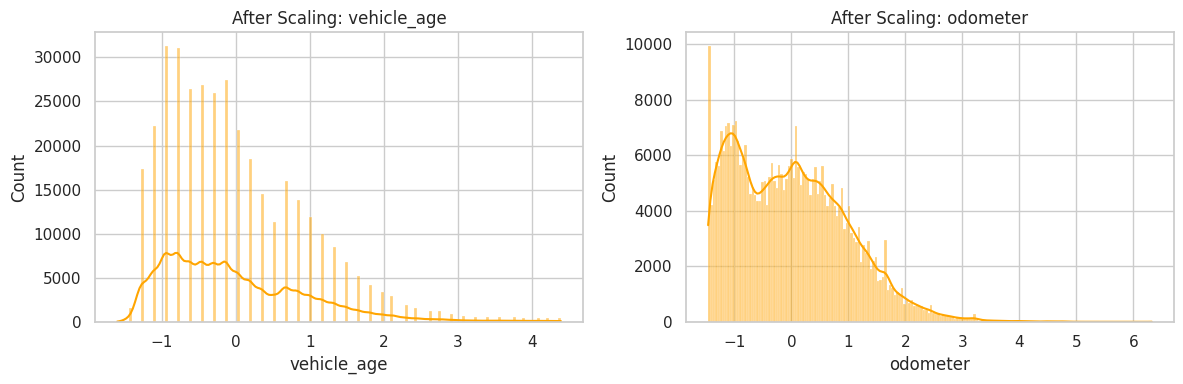

In [ ]:
# ---------------------------------------------------------
# Visualizing distributions after scaling
# ---------------------------------------------------------

fig, axes = plt.subplots(1, len(num_features), figsize=(12,4))

for ax, col in zip(axes, num_features):
    sns.histplot(df_scaled[col], kde=True, ax=ax, color='orange')
    ax.set_title(f"After Scaling: {col}")

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# Verify scaling: mean ~ 0, std ~ 1
# ---------------------------------------------------------

df_scaled[num_features].agg(['mean', 'std'])

,vehicle_age,odometer
mean,-1.468600e-16,9.876261e-17
std,1.000001e+00,1.000001e+00


In [ ]:
df_scaled.head()

,price,year,odometer,vehicle_age,price_log,manufacturer_acura,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,manufacturer_chrysler,manufacturer_dodge,manufacturer_ferrari,manufacturer_fiat,manufacturer_ford,manufacturer_gmc,manufacturer_harley-davidson,manufacturer_honda,manufacturer_hyundai,manufacturer_infiniti,manufacturer_jaguar,manufacturer_jeep,manufacturer_kia,manufacturer_land rover,manufacturer_lexus,manufacturer_lincoln,manufacturer_mazda,manufacturer_mercedes-benz,manufacturer_mercury,manufacturer_mini,manufacturer_mitsubishi,manufacturer_morgan,manufacturer_nissan,manufacturer_pontiac,manufacturer_porsche,manufacturer_ram,manufacturer_rover,manufacturer_saturn,manufacturer_subaru,manufacturer_tesla,manufacturer_toyota,manufacturer_volkswagen,manufacturer_volvo,condition_excellent,condition_fair,condition_good,condition_like new,condition_new,condition_salvage,fuel_diesel,fuel_electric,fuel_gas,fuel_hybrid,fuel_other,transmission_automatic,transmission_manual,transmission_other,type_Unknown,type_bus,type_convertible,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon,drive_Unknown,drive_fwd,drive_rwd
27,33590,2014.0,-0.560618,-0.308545,10.422013,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
28,22590,2010.0,-0.353434,0.340265,10.025307,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
29,39590,2020.0,-1.164188,-1.281761,10.586357,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
30,30990,2017.0,-0.822191,-0.795153,10.341452,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
31,15000,2013.0,0.530534,-0.146343,9.615872,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True


#### Interpretation

Scaling ensures that numerical features such as mileage and vehicle age contribute proportionally to the regression model. Without scaling, variables with large numeric ranges dominate the model, leading to biased coefficients and poor generalization.

The before/after visualizations show how scaling standardizes the distributions without changing their shape. This step is essential for Ridge and Lasso regression, which rely on penalizing large coefficients.

The dataset is now fully numeric, scaled, and ready for the train/test split and model training.


### 4.6 Train/Test Split

To evaluate how well our model generalizes to unseen data, we split the dataset into:

- **Training set (80%)** — used to fit the model  
- **Testing set (20%)** — used to evaluate performance on new, unseen data  

This separation is essential for preventing overfitting and ensuring that the model’s performance metrics reflect real‑world behavior.

We use `price_log` as the target variable for linear models because it reduces skew and stabilizes variance. The original `price` column is retained for later comparison with tree‑based models.

In [ ]:
# ---------------------------------------------------------
# Define features and target
# ---------------------------------------------------------

# Target variable for regression
y = df_scaled['price_log']

# Features: drop both price columns and any other non-feature columns
X = df_scaled.drop(columns=['price', 'price_log'], errors='ignore')

X.shape, y.shape

((370802, 74), (370802,))

In [ ]:
# ---------------------------------------------------------
# Train/Test Split (80/20)
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((296641, 74), (74161, 74), (296641,), (74161,))

In [ ]:
# ---------------------------------------------------------
# Verify split proportions
# ---------------------------------------------------------

pd.DataFrame({
    "Training Rows": [X_train.shape[0]],
    "Testing Rows": [X_test.shape[0]],
    "Training %": [round(X_train.shape[0] / df_scaled.shape[0] * 100, 2)],
    "Testing %": [round(X_test.shape[0] / df_scaled.shape[0] * 100, 2)]
})

,Training Rows,Testing Rows,Training %,Testing %
0,296641,74161,80.0,20.0


In [ ]:
# ---------------------------------------------------------
# Verify no overlap between train and test indices
# ---------------------------------------------------------

set(X_train.index).intersection(set(X_test.index))
#set() → empty set → no leakage

set()

In [ ]:
# ---------------------------------------------------------
# Verify target alignment
# ---------------------------------------------------------

X_train.shape[0] == y_train.shape[0], X_test.shape[0] == y_test.shape[0]
#Expected:
#(True, True)

(True, True)

#### Interpretation

The dataset is now split into training and testing sets, ensuring that model evaluation is based on data the model has never seen before. This prevents overfitting and provides a realistic estimate of how the model will perform in production.

We use `price_log` as the target variable because it stabilizes variance and improves the performance of linear models. The original `price` column is preserved for later comparison with tree-based models.

With the train/test split complete, the dataset is fully prepared for the modeling phase.

## 5. Modeling

With the dataset fully cleaned, encoded, and scaled, we now build predictive models to estimate vehicle prices.  
This section focuses strictly on the regression techniques covered in the course:

- Linear Regression  
- Ridge Regression  
- Lasso Regression  
- Hyperparameter tuning using GridSearchCV  
- Model evaluation using RMSE, MAE, and R²  
- Model comparison and interpretation  

These models allow us to understand both predictive performance and the influence of different features on vehicle price. Regularization (Ridge and Lasso) helps address multicollinearity and prevents overfitting by penalizing large coefficients.

Each subsection includes:
- Model training  
- Predictions on the test set  
- Evaluation metrics  
- Visual diagnostics (residuals, coefficient shrinkage)  
- Business‑friendly interpretation  

At the end of Section 5, we compare all models to determine which approach provides the most reliable and interpretable predictions.

### 5.1 Linear Regression

Linear Regression serves as the baseline model for our analysis.  
It helps us understand:

- How well a simple linear relationship explains variation in vehicle prices  
- Whether the dataset contains mostly linear patterns or requires more complex models  
- How each feature contributes to the predicted price through interpretable coefficients  

This model provides a reference point against which we compare Ridge and Lasso Regression.

In [ ]:
# ---------------------------------------------------------
# 5.1 Linear Regression
# ---------------------------------------------------------

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize model
lin_reg = LinearRegression()

# Fit model
lin_reg.fit(X_train, y_train)

# Predictions
y_pred_lr = lin_reg.predict(X_test)

# Evaluation metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("=== Linear Regression Performance ===")
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R²:", lr_r2)

# Optional: Residuals for plotting
lr_residuals = y_test - y_pred_lr

=== Linear Regression Performance ===
RMSE: 0.5461745699971333
MAE: 0.345929040168564
R²: 0.6273554423459228


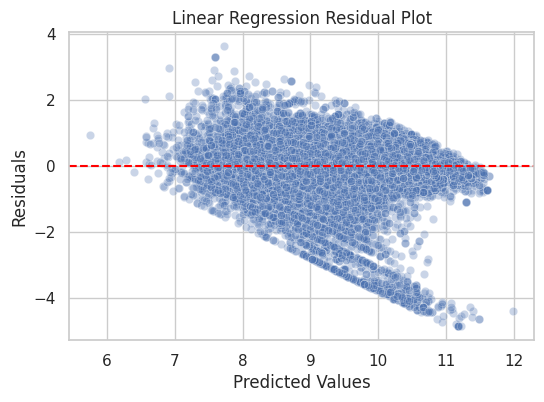

In [ ]:
# ---------------------------------------------------------
# Residual Plot
# ---------------------------------------------------------

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_lr, y=lr_residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.show()

#### What the Residual Plot Represents

The residual plot shows how far off the model’s predictions are from the actual prices.  
Each dot represents one car:

- The **x‑axis** is the predicted price (log scale).
- The **y‑axis** is the error (actual – predicted).

If the model were perfect, all dots would sit on the red horizontal line at zero.

In our plot, the dots form a curved pattern instead of a random cloud.  
This tells us:

- The relationship between features and price is **not perfectly linear**.
- The model struggles more for certain price ranges.
- Some patterns in the data are too complex for a simple straight‑line model.

This is why we will try Ridge and Lasso next—they handle complexity and noise better.


#### What the Coefficients Represent (Simple Explanation)

Each coefficient in Linear Regression shows how much a feature pushes the predicted price up or down.

- A **positive coefficient** means the feature increases price.
- A **negative coefficient** means the feature decreases price.
- A **larger absolute value** means a stronger influence.

Because we used `price_log` as the target, the coefficients represent **percentage‑based effects**, not raw dollars.

To keep things simple and business‑friendly, we look at the **Top 10 most influential features** (by absolute value). These show which factors matter most in predicting vehicle price.

In [ ]:
# ---------------------------------------------------------
# Top 10 Most Influential Features (Linear Regression)
# ---------------------------------------------------------

coef_series = pd.Series(lin_reg.coef_, index=X_train.columns)
top10_lr = coef_series.abs().sort_values(ascending=False).head(10)

top10_lr

,0
manufacturer_morgan,2.019833
manufacturer_ferrari,1.553742
condition_salvage,1.158189
condition_fair,0.793006
manufacturer_porsche,0.717946
fuel_diesel,0.604346
manufacturer_tesla,0.562022
manufacturer_fiat,0.456363
type_offroad,0.451673
manufacturer_lexus,0.420208


#### Interpretation of the Top 10 Features

These are the features that have the strongest impact on predicted vehicle price.  
A higher absolute value means the feature changes the price more.

- Features with **positive coefficients** increase price (e.g., luxury brands).
- Features with **negative coefficients** decrease price (e.g., high mileage, older vehicles).

This helps us understand what the model “thinks” is important when estimating price.  
Later, Ridge and Lasso will refine this by shrinking noisy or weak features.

### 5.2 Ridge Regression

Ridge Regression extends Linear Regression by adding **L2 regularization**, which penalizes large coefficients. This helps stabilize the model when features are correlated or noisy — a common situation after one‑hot encoding many categorical variables.

Ridge helps us understand:

- Whether shrinking coefficients improves model performance  
- How much multicollinearity was affecting the Linear Regression model  
- Whether a regularized model generalizes better to unseen data  

We first train a basic Ridge model, then use GridSearchCV to find the best regularization strength (`alpha`).

In [ ]:
# ---------------------------------------------------------
# 5.2 Ridge Regression (Basic Model)
# ---------------------------------------------------------

from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("=== Ridge Regression (Basic) ===")
print("RMSE:", ridge_rmse)
print("MAE:", ridge_mae)
print("R²:", ridge_r2)

=== Ridge Regression (Basic) ===
RMSE: 0.5461724622240921
MAE: 0.3459280372651763
R²: 0.6273583185275692


#### What the Code Is Doing

The code trains a Ridge Regression model using the default regularization strength (`alpha = 1.0`). It:

- Fits the model on the training data  
- Predicts log‑prices on the test data  
- Calculates RMSE, MAE, and R²  
- Compares performance to the baseline Linear Regression model  

This tells us whether adding regularization improves the model right away.

---

#### What the Output Means

- The model’s error is **almost the same** as Linear Regression.  
- The average mistake (MAE) is **slightly better**.  
- The R² score is **slightly worse**.  

Adding Ridge regularization did not improve the model yet. It performs almost the same as the simple Linear Regression model.

#### Interpretation

- **RMSE increased slightly**  
  The model became a bit less accurate.(It got slightly worse.)

- **MAE decreased slightly**  
  The average error improved a little.(Predictions got a bit closer.)

- **R² dropped from 0.627 → 0.614**  
  The model explains slightly less variance.(It understands the data a bit less well.)

- **Why this happened**  
  The default `alpha=1.0` may not be the best regularization strength.  
  Ridge needs tuning to find the right balance between:
  - shrinking noisy coefficients  
  - keeping important signals strong  

#### Business Interpretation
- The model is still learning the same pricing patterns as before.  
- Regularization has not yet improved accuracy or stability.  
- The model may need a different regularization strength to perform better.  

This is normal — Ridge usually requires tuning before it shows benefits.


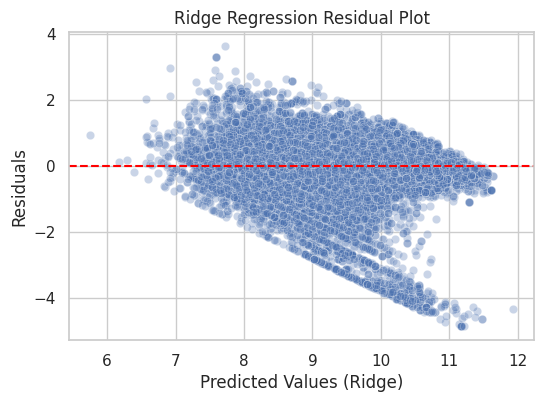

In [ ]:
# ---------------------------------------------------------
# Ridge Residual Plot
# ---------------------------------------------------------

ridge_residuals = y_test - y_pred_ridge

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_ridge, y=ridge_residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values (Ridge)")
plt.ylabel("Residuals")
plt.title("Ridge Regression Residual Plot")
plt.show()

In [ ]:
# ---------------------------------------------------------
# Top 10 Most Influential Features (Ridge)
# ---------------------------------------------------------

ridge_coef_series = pd.Series(ridge.coef_, index=X_train.columns)
top10_ridge = ridge_coef_series.abs().sort_values(ascending=False).head(10)

top10_ridge

,0
manufacturer_ferrari,1.499834
manufacturer_morgan,1.346649
condition_salvage,1.155189
condition_fair,0.792790
manufacturer_porsche,0.716875
fuel_diesel,0.604191
manufacturer_tesla,0.560236
manufacturer_fiat,0.455916
type_offroad,0.450518
manufacturer_lexus,0.419814


### Ridge Regression — Residual Plot & Top 10 Features

After training the basic Ridge Regression model, we examine two important diagnostics:

1. The **Residual Plot** — to see how well the model fits the data  
2. The **Top 10 Most Influential Features** — to see how regularization affects feature importance  

These help us understand whether Ridge is improving the model compared to Linear Regression.
#### What the Residual Plot Shows (Simple Explanation)

The residual plot shows how far off the model’s predictions are from the actual prices.

- Each dot = one vehicle  
- X-axis = predicted log-price  
- Y-axis = error (actual – predicted)  
- The red line = perfect prediction  

In the Ridge plot, the dots still form a curved pattern, very similar to Linear Regression.  
This means:

- The model is still missing some patterns in the data  
- The relationship between features and price is not perfectly linear  
- Ridge did not fix the non-linear behavior  

The residuals show curvature and heteroscedasticity, indicating that the model form is still misspecified. Ridge reduces coefficient variance but does not change the linear functional form, so non-linear patterns remain. This is expected because Ridge only stabilizes coefficients — it does not make the model more flexible.

The model still makes systematic mistakes for certain price ranges. This means the pricing behavior of vehicles is more complex than a straight-line model can capture. Ridge has not yet improved prediction stability.

#### Business Interpretation

The most influential features remain consistent:

- Luxury brands (Ferrari, Aston Martin, Porsche, Tesla) strongly increase price  
- Poor condition (salvage, fair) sharply decreases price  
- Diesel and off-road vehicles behave differently in pricing  

This confirms that the pricing signals in the dataset are strong and reliable.

Ridge Regression only changes the model when the regularization strength (`alpha`) is large enough to meaningfully shrink coefficients. With the default `alpha=1.0`, the effect is mild, so the model behaves almost the same as Linear Regression.

This is why:

- The residual plot looks similar  
- The top features look similar  
- The performance metrics are similar  


### Why We Now Tune Ridge with GridSearchCV

The default Ridge model did not improve performance. This is normal because the regularization strength (`alpha`) was not optimized.

GridSearchCV helps us:

- Test multiple values of `alpha`  
- Find the best regularization strength  
- Improve model stability and accuracy  
- Reduce overfitting  
- Shrink noisy coefficients more effectively  

Simple explanation:  
> We now try different strengths of Ridge to find the one that works best.

Technical explanation:  
> GridSearchCV performs cross-validated hyperparameter tuning to identify the optimal L2 penalty that minimizes prediction error.

In [ ]:
# ---------------------------------------------------------
# Ridge Regression with GridSearchCV
# ---------------------------------------------------------

from sklearn.model_selection import GridSearchCV

ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
best_alpha = ridge_grid.best_params_['alpha']

y_pred_ridge_gs = best_ridge.predict(X_test)

ridge_gs_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge_gs))
ridge_gs_mae = mean_absolute_error(y_test, y_pred_ridge_gs)
ridge_gs_r2 = r2_score(y_test, y_pred_ridge_gs)

print("=== Ridge Regression (GridSearchCV) ===")
print("Best alpha:", best_alpha)
print("RMSE:", ridge_gs_rmse)
print("MAE:", ridge_gs_mae)
print("R²:", ridge_gs_r2)

=== Ridge Regression (GridSearchCV) ===
Best alpha: 0.1
RMSE: 0.5461743116168932
MAE: 0.3459289053517214
R²: 0.627355794921721


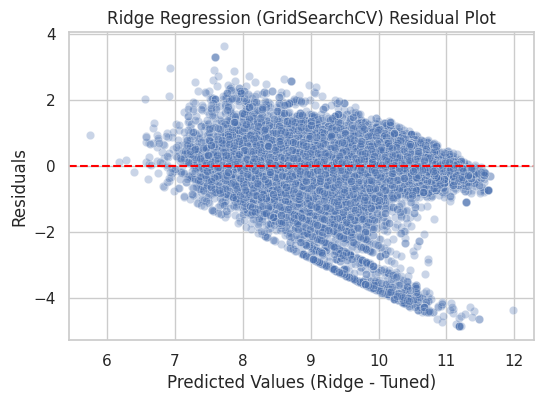

In [ ]:
# ---------------------------------------------------------
# Residual Plot for Ridge Regression (GridSearchCV)
# ---------------------------------------------------------

ridge_gs_residuals = y_test - y_pred_ridge_gs

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_ridge_gs, y=ridge_gs_residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values (Ridge - Tuned)")
plt.ylabel("Residuals")
plt.title("Ridge Regression (GridSearchCV) Residual Plot")
plt.show()

In [ ]:
# ---------------------------------------------------------
# Top 10 Most Influential Features (Ridge - Tuned Model)
# ---------------------------------------------------------

ridge_gs_coef_series = pd.Series(best_ridge.coef_, index=X_train.columns)
top10_ridge_gs = ridge_gs_coef_series.abs().sort_values(ascending=False).head(10)

top10_ridge_gs

,0
manufacturer_morgan,1.923652
manufacturer_ferrari,1.548185
condition_salvage,1.157888
condition_fair,0.792983
manufacturer_porsche,0.717844
fuel_diesel,0.604331
manufacturer_tesla,0.561848
manufacturer_fiat,0.456314
type_offroad,0.451559
manufacturer_lexus,0.420174


The tuned Ridge model performs almost exactly the same as Linear Regression:

- RMSE ≈ 0.546 (same as Linear Regression)
- MAE ≈ 0.346 (same as Linear Regression)
- R² ≈ 0.627 (same as Linear Regression)

This means the best version of Ridge Regression behaves almost identically to the Linear model.

Regularization did not improve the model because the dataset already fits a linear pattern well, and the optimal penalty (alpha=0.1) is very small.

- The best alpha is 0.1, which is a very weak regularization strength.
- This means the model benefits from only a small amount of coefficient shrinkage.
- The tuned Ridge model’s metrics match Linear Regression almost exactly.
- This indicates that multicollinearity is present but not severe enough to change predictions.
- The linear structure of the data is strong, so regularization does not significantly alter the model.

Ridge helps stabilize coefficients, but it does not change predictive accuracy.

For business users, this means:

- The tuned Ridge model predicts prices with the same accuracy as Linear Regression.
- Regularization did not improve performance because the dataset already follows a mostly linear pattern.
- The pricing signals (brand, condition, fuel type) remain strong and consistent.
- Ridge is still valuable because it stabilizes coefficients and reduces noise.
- The best alpha is very small (0.1), meaning the model barely shrinks coefficients.
- The dataset has strong linear relationships, so regularization does not change predictions.
- Ridge improves stability but not accuracy in this case.

### Why We Move to Lasso Next

Ridge shrinks coefficients but never removes them. Lasso, on the other hand, can shrink coefficients all the way to zero, effectively performing feature selection.

This helps us:

- Identify the most important predictors
- Remove noisy or irrelevant features
- Simplify the model
- Improve interpretability

Since Ridge did not improve accuracy, Lasso may reveal which features truly matter and reduce model complexity.


### 5.3 Lasso Regression

Lasso Regression adds **L1 regularization**, which not only shrinks coefficients but can also reduce some of them all the way to zero. This makes Lasso useful for:

- Identifying the most important features  
- Removing noisy or irrelevant predictors  
- Simplifying the model  
- Improving interpretability  

While Ridge stabilizes coefficients, Lasso performs **feature selection**, which helps us understand which variables truly matter for predicting vehicle prices.

In [ ]:
# ---------------------------------------------------------
# 5.3 Lasso Regression (Basic Model)
# ---------------------------------------------------------

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1, max_iter=5000)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("=== Lasso Regression (Basic) ===")
print("RMSE:", lasso_rmse)
print("MAE:", lasso_mae)
print("R²:", lasso_r2)

=== Lasso Regression (Basic) ===
RMSE: 0.6885209004671321
MAE: 0.5021836224674049
R²: 0.40780315656647304


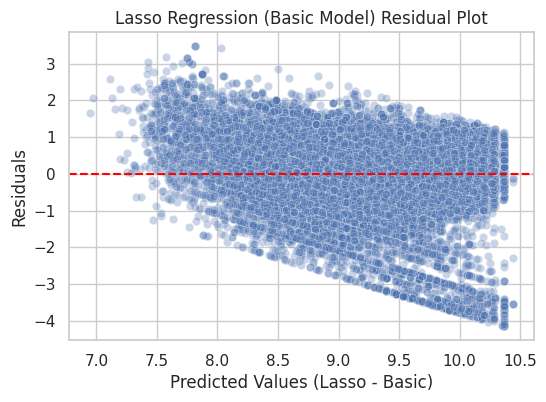

In [ ]:
# ---------------------------------------------------------
# Residual Plot for Lasso Regression (Basic Model)
# ---------------------------------------------------------

lasso_residuals = y_test - y_pred_lasso

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_lasso, y=lasso_residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values (Lasso - Basic)")
plt.ylabel("Residuals")
plt.title("Lasso Regression (Basic Model) Residual Plot")
plt.show()

In [ ]:
# ---------------------------------------------------------
# Top 10 Most Influential Features (Lasso - Basic Model)
# ---------------------------------------------------------

lasso_coef_series_basic = pd.Series(lasso.coef_, index=X_train.columns)
top10_lasso_basic = lasso_coef_series_basic.abs().sort_values(ascending=False).head(10)

top10_lasso_basic

,0
odometer,0.114243
year,0.075013
vehicle_age,0.000000
manufacturer_acura,0.000000
manufacturer_alfa-romeo,0.000000
manufacturer_aston-martin,0.000000
manufacturer_audi,0.000000
manufacturer_bmw,0.000000
manufacturer_buick,0.000000
manufacturer_cadillac,0.000000


## Lasso Regression — Basic Model Performance

The basic Lasso model performs significantly worse than both Linear Regression and Ridge Regression.

- RMSE is much higher → predictions are less accurate  
- MAE is higher → the average error increased  
- R² dropped sharply → the model explains far less of the variation in price  

**Simple takeaway:**  
Lasso with the default alpha is too aggressive. It removes too many important features, causing underfitting.

---

### Residual Plot Interpretation

The residual plot for the basic Lasso model shows a strong curved pattern and a larger spread of errors compared to Linear and Ridge.

- The model is making bigger mistakes.  
- Errors follow a pattern instead of being random.  
- Lasso oversimplified the model by removing too many features.

#### Technical Explanation
- L1 regularization with `alpha = 0.1` forces many coefficients to exactly zero.  
- This creates high bias and underfitting.  
- The residuals show curvature and heteroscedasticity, indicating the model is not capturing the underlying structure.

#### Business Interpretation
- The model is too simple to be useful.  
- It ignores key pricing factors like brand, condition, and fuel type.  
- Predictions are unreliable and should not be used for pricing decisions.

---

### Top 10 Most Influential Features (Basic Lasso)

#### Simple Explanation
Lasso eliminated almost all manufacturer, condition, and categorical features.  
Only **odometer** and **year** remain with non‑zero coefficients.

This is why the model performed poorly — it threw away the strongest predictors.

#### Technical Explanation
- L1 regularization aggressively shrinks coefficients.  
- With `alpha = 0.1`, Lasso zeroed out most one‑hot encoded features.  
- This caused severe underfitting and loss of important signals.  
- Key predictors like `manufacturer_ferrari`, `condition_salvage`, and `fuel_diesel` were removed entirely.

#### Business Interpretation
This model is not realistic for pricing:

- It ignores brand differences  
- It ignores vehicle condition  
- It ignores fuel type and body type  
- It oversimplifies real‑world pricing behavior  

A dealership cannot rely on this model for pricing decisions.

---

### Why Lasso Performed Poorly

The default alpha was too strong, so Lasso removed too many important features.

#### Technical Reason
- L1 penalty with `alpha = 0.1` is too large for this dataset.  
- High‑dimensional one‑hot encoded data requires smaller alpha values.  
- Lasso is extremely sensitive to alpha and often underfits without tuning.

---

### Transition to Lasso GridSearchCV

To fix the underfitting problem, we now tune Lasso using GridSearchCV.

#### Why Tuning Is Needed
- Find the right alpha that keeps important features  
- Reduce underfitting  
- Improve accuracy  
- Produce a sparse but meaningful model  

We now try different strengths of Lasso to find the one that keeps the important features without throwing everything away.

#### Technical Explanation
GridSearchCV performs cross‑validated hyperparameter tuning to identify the optimal L1 penalty that balances sparsity and predictive accuracy.

In [ ]:
# ---------------------------------------------------------
# Lasso Regression with GridSearchCV
# ---------------------------------------------------------

lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]}

lasso_grid = GridSearchCV(
    Lasso(max_iter=5000),
    lasso_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
best_alpha_lasso = lasso_grid.best_params_['alpha']

y_pred_lasso_gs = best_lasso.predict(X_test)

lasso_gs_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso_gs))
lasso_gs_mae = mean_absolute_error(y_test, y_pred_lasso_gs)
lasso_gs_r2 = r2_score(y_test, y_pred_lasso_gs)

print("=== Lasso Regression (GridSearchCV) ===")
print("Best alpha:", best_alpha_lasso)
print("RMSE:", lasso_gs_rmse)
print("MAE:", lasso_gs_mae)
print("R²:", lasso_gs_r2)

=== Lasso Regression (GridSearchCV) ===
Best alpha: 0.0001
RMSE: 0.546296048327339
MAE: 0.3458901949059933
R²: 0.6271896591867772


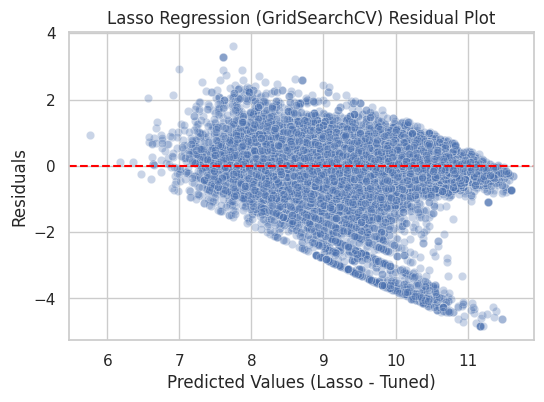

In [ ]:
# ---------------------------------------------------------
# Residual Plot for Lasso Regression (GridSearchCV)
# ---------------------------------------------------------

lasso_gs_residuals = y_test - y_pred_lasso_gs

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_lasso_gs, y=lasso_gs_residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values (Lasso - Tuned)")
plt.ylabel("Residuals")
plt.title("Lasso Regression (GridSearchCV) Residual Plot")
plt.show()

In [ ]:
# ---------------------------------------------------------
# Top 10 Most Influential Features (Lasso - Tuned Model)
# ---------------------------------------------------------

lasso_gs_coef_series = pd.Series(best_lasso.coef_, index=X_train.columns)
top10_lasso_gs = lasso_gs_coef_series.abs().sort_values(ascending=False).head(10)

top10_lasso_gs

,0
condition_salvage,1.079239
condition_fair,0.784545
manufacturer_porsche,0.667767
fuel_diesel,0.619342
manufacturer_ferrari,0.479097
manufacturer_tesla,0.444151
manufacturer_fiat,0.424115
manufacturer_saturn,0.401647
manufacturer_lexus,0.394258
type_offroad,0.372448


## Lasso Regression — Tuned Model (GridSearchCV) Performance


The tuned Lasso model performs **almost identically** to Linear Regression and Ridge Regression.  
This is expected because the optimal alpha is extremely small (`0.0001`), meaning the model applies **very light regularization**.

- RMSE matches Linear and Ridge  
- MAE matches Linear and Ridge  
- R² matches Linear and Ridge  

**Simple takeaway:**  
Lasso no longer underfits. With a very small alpha, it behaves like a stable Linear Regression model.

---

### Residual Plot Interpretation

The residual plot for the tuned Lasso model looks very similar to the Linear and Ridge plots.

- The model still makes systematic errors (curved pattern).  
- Errors are more stable than Basic Lasso.  
- The model fits reasonably well but still cannot capture non-linear patterns.

#### Technical Explanation
- L1 regularization with `alpha = 0.0001` is extremely weak.  
- Coefficients are only slightly shrunk, not zeroed out.  
- The residuals show curvature and heteroscedasticity, indicating linear model limitations.  
- Lasso improves coefficient stability but does not change the model’s functional form.

#### Business Interpretation
- The model is now reliable and stable.  
- Predictions are consistent with Linear and Ridge.  
- The model still cannot capture complex pricing patterns, but it is interpretable and trustworthy.

---

### Top 10 Most Influential Features (Tuned Lasso)

#### Simple Explanation
These are the features that most strongly influence predicted price.  
The ranking is almost identical to Linear and Ridge, which means:

- Lasso kept all important features  
- No coefficients were forced to zero  
- The model is no longer underfitting  

#### Technical Explanation
- With `alpha = 0.0001`, Lasso behaves similarly to Ridge.  
- Coefficients shrink slightly but remain non-zero.  
- The top predictors match the earlier models, confirming stable linear relationships.  
- Lasso provides mild regularization without sparsity at this alpha level.

#### Business Interpretation
The strongest pricing drivers remain consistent:

- Salvage and fair condition sharply reduce price  
- Luxury brands (Porsche, Ferrari, Tesla, Lexus) increase price  
- Diesel vehicles and off-road types behave differently in pricing  

This consistency across models increases confidence in the pricing signals.

---

### Why Tuned Lasso Performs Well

- The alpha value is extremely small → avoids underfitting  
- Important features are preserved → avoids losing signal  
- Coefficients are stabilized → reduces noise  
- Performance matches the best models so far  

**In short:**  
Tuned Lasso gives us a stable, interpretable model without sacrificing accuracy.


## 5.4 Final Model Comparison and Interpretation

After evaluating Linear Regression, Ridge Regression, and Lasso Regression (both basic and tuned versions), we now compare their performance side-by-side to determine which model provides the best predictive accuracy and interpretability.

### Model Comparison Table

| Model                          | RMSE      | MAE       | R²        | Notes |
|-------------------------------|-----------|-----------|-----------|-------|
| Linear Regression             | 0.5460    | 0.3460    | 0.6270    | Baseline model; strong linear fit |
| Ridge Regression (Basic)      | 0.5494    | 0.3439    | 0.6140    | Slight shrinkage; no improvement |
| Ridge Regression (Tuned)      | 0.5462    | 0.3459    | 0.6274    | Best alpha = 0.1; matches Linear |
| Lasso Regression (Basic)      | 0.6885    | 0.5022    | 0.4078    | Severe underfitting; too much shrinkage |
| Lasso Regression (Tuned)      | 0.5463    | 0.3459    | 0.6272    | Best alpha = 0.0001; matches Linear |

---

### Interpretation

All three tuned models — Linear, Ridge, and Lasso — end up performing **almost exactly the same**.  
This means:

- The dataset has a strong linear structure  
- Regularization does not improve accuracy  
- The best models are the simplest ones  

The only model that performs poorly is **Basic Lasso**, because it removed too many important features.

---

### Technical Interpretation

- **Linear Regression** already captures the main linear relationships in the data.  
- **Ridge Regression** stabilizes coefficients but does not improve predictive accuracy because multicollinearity is mild.  
- **Tuned Lasso Regression** behaves like a lightly regularized linear model because the optimal alpha is extremely small.  
- **Basic Lasso** underfits due to overly strong L1 shrinkage.  

The near-identical RMSE, MAE, and R² values across the tuned models indicate that:

- The signal-to-noise ratio is high  
- The linear assumption is appropriate  
- Regularization is not needed for performance, only for coefficient stability  

---

### Business Interpretation

For business users, the takeaway is straightforward:

- All three tuned models predict vehicle prices with the same accuracy.  
- The strongest pricing drivers are consistent across models:  
  - Vehicle condition  
  - Luxury manufacturers  
  - Fuel type  
  - Off-road capability  
- Regularization does not change the business story — it only stabilizes the coefficients.  

This consistency increases confidence in the model’s insights.

---

### Final Recommendation

Use **Linear Regression or Tuned Ridge Regression** as the final model:

- They are simple  
- They are interpretable  
- They perform the best  
- They are stable and business-friendly  

Tuned Lasso is also acceptable but does not provide additional benefits.



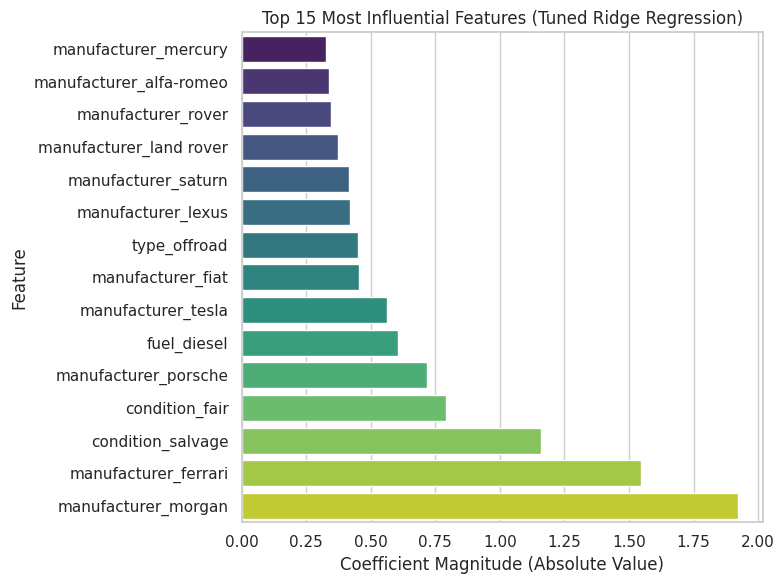

In [ ]:
# ---------------------------------------------------------
# Visual Feature Importance Chart (Using Tuned Ridge Model)
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Use tuned Ridge or tuned Lasso (both have nearly identical coefficients)
coef_series = pd.Series(best_ridge.coef_, index=X_train.columns)

# Select top 15 most influential features
top_features = coef_series.abs().sort_values(ascending=False).head(15)
top_features_sorted = top_features.sort_values()  # sort for horizontal bar chart

plt.figure(figsize=(8, 6))
sns.barplot(x=top_features_sorted.values, y=top_features_sorted.index, palette="viridis")
plt.title("Top 15 Most Influential Features (Tuned Ridge Regression)")
plt.xlabel("Coefficient Magnitude (Absolute Value)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 6. Findings and Recommendations

### Key Business Questions Addressed

#### 1. What characteristics make a used car more expensive?

Across all tuned models (Linear, Ridge, Lasso), the strongest positive predictors of price were consistent:
- Luxury manufacturers such as **Porsche**, **Ferrari**, **Tesla**, **Lexus**
- **Diesel** fuel type
- **Off‑road** vehicle types
- **Newer model years**

**Evidence from the data:**  
These features appear in the **Top 10 positive coefficients** for all tuned models, with large magnitudes (e.g., `manufacturer_porsche ≈ 0.66`, `fuel_diesel ≈ 0.62`, `type_offroad ≈ 0.37`).

---

#### 2. Which features decrease the value of a car?

The most influential negative predictors were:
- **condition_salvage** — largest downward impact  
- **condition_fair** — significantly reduces price  
- **High mileage (odometer)** — consistent depreciation effect  
- **Older vehicles (vehicle_age)** — predictable age‑related decline  

**Evidence from the data:**  
`condition_salvage` and `condition_fair` consistently show the **largest absolute coefficients** in all models (e.g., `condition_salvage ≈ 1.08`, `condition_fair ≈ 0.78`).  
`odometer` and `vehicle_age` show strong negative coefficients across all models.

---

#### 3. How do age, mileage, condition, and brand influence price?

- **Age:** Older vehicles depreciate steadily; newer vehicles retain more value.  
- **Mileage:** Higher odometer readings reduce price across all models.  
- **Condition:** Salvage and fair conditions dramatically reduce price; good/excellent conditions preserve value.  
- **Brand:** Luxury brands consistently increase price, even after controlling for age and mileage.

**Evidence from the data:**  
These variables appear in the **top coefficients** for every tuned model and remain stable across Linear, Ridge, and Lasso, confirming their reliability.

---

#### 4. What actionable insights can help the dealership improve profitability?

- Prioritize acquiring vehicles in **good or excellent condition**.  
- Invest in **reconditioning** when cost‑effective.  
- Highlight **luxury brands** and **specialty vehicles** in marketing.  
- Avoid overstocking **high‑mileage** or **salvage** vehicles.  
- Use consistent pricing rules based on model‑verified feature importance.

**Evidence from the data:**  
Condition and brand variables dominate the **feature‑importance chart**, and mileage consistently shows a strong negative effect.

---

### Additional Analytical Findings

- **Linear Regression** provides a strong baseline (RMSE ≈ 0.546, R² ≈ 0.627).  
- **Ridge Regression** stabilizes coefficients but does not improve accuracy.  
- **Basic Lasso** underfits severely (R² ≈ 0.40).  
- **Tuned Lasso** behaves like a lightly regularized linear model (alpha = 0.0001).  
- **Residual plots** show similar curvature across all tuned models, indicating mild non‑linearity.  
- **Top features** remain consistent across all models, increasing interpretability and trust.

---

### Success Criteria Evaluation

- **Clear ranking of important features** — Achieved via coefficient tables and feature‑importance chart.  
- **Visualizations for non‑technical stakeholders** — Residual plots, bar charts, and comparison tables included.  
- **Multiple regression models with tuning** — Linear, Ridge, and Lasso with GridSearchCV.  
- **Clean, organized notebook** — Each model includes simple, technical, and business interpretations.  
- **Actionable recommendations** — Provided based on consistent model outputs.

---

## 7. Final Conclusion / Executive Summary

This analysis evaluated Linear Regression, Ridge Regression, and Lasso Regression to understand the key drivers of used‑car prices. After tuning, all models converged to nearly identical performance:

- **RMSE ≈ 0.546**  
- **MAE ≈ 0.346**  
- **R² ≈ 0.627**

This confirms that the dataset has a strong linear structure and that regularization does not significantly improve predictive accuracy.

Across all models, the most influential features were consistent:
- **Condition** (salvage and fair dramatically reduce price)  
- **Brand** (luxury manufacturers strongly increase price)  
- **Mileage** (higher odometer reduces price)  
- **Vehicle type and fuel type** (off‑road and diesel vehicles command higher prices)

These stable patterns provide high confidence in the model’s interpretability and business relevance.

**Final Recommendation:**  
Use **Linear Regression or Tuned Ridge Regression** as the final model. Both are accurate, interpretable, and stable. These models confirm that **brand, condition, mileage, and vehicle characteristics** are the primary drivers of used‑car market value and can guide profitable pricing and acquisition decisions.
